<a href="https://www.kaggle.com/code/lalit7881/nvidia-gpu-sales-data-2026-eda?scriptVersionId=333271639" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uditjain13/nvidia-gpu-sales-synthetic-2026/nvidia_gpu_sales_synthetic_2026.csv
/kaggle/input/datasets/uditjain13/nvidia-gpu-sales-synthetic-2026/generate_data.py


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/uditjain13/nvidia-gpu-sales-synthetic-2026/nvidia_gpu_sales_synthetic_2026.csv")

In [3]:
df.head()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,1796.91,12.38,Low Stock,4.0,12,Software Bundle,14375.30
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.0,12,NaN,32799.82
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,1308.25,30.96,Sold Out,4.0,12,NaN,39247.64
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,29202.11,8.16,Low Stock,4.5,24,NaN,146010.54
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,27778.73,2.88,In Stock,4.5,36,NaN,250008.56


In [4]:
df.tail()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
6995,6996,2026-06-28,RTX 5070,Consumer Gaming,2025,Europe,System Integrator/OEM,Content Creation,19,549,764.54,39.26,Backordered,3.5,24,NaN,14526.24
6996,6997,2026-06-28,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Content Creation,12,999,1354.06,35.54,Sold Out,3.5,12,Extended Warranty,16248.74
6997,6998,2026-06-28,RTX 5070,Consumer Gaming,2025,China,System Integrator/OEM,Gaming,49,549,558.18,1.67,In Stock,4.5,36,NaN,27350.88
6998,6999,2026-06-29,RTX 5070,Consumer Gaming,2025,Asia-Pacific (ex-China),Retail/Etail,Gaming,23,549,604.02,10.02,Low Stock,5.0,12,NaN,13892.52
6999,7000,2026-06-29,H100 SXM,Data Center AI,2022,Europe,System Integrator/OEM,Hyperscale Datacenter,4,27000,37542.17,39.05,Backordered,3.5,36,NaN,150168.66


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sale_id                      7000 non-null   int64  
 1   sale_date                    7000 non-null   object 
 2   gpu_model                    7000 non-null   object 
 3   gpu_family                   7000 non-null   object 
 4   launch_year                  7000 non-null   int64  
 5   region                       7000 non-null   object 
 6   sales_channel                7000 non-null   object 
 7   customer_segment             7000 non-null   object 
 8   units_sold                   7000 non-null   int64  
 9   msrp_usd                     7000 non-null   int64  
 10  avg_street_price_usd         7000 non-null   float64
 11  price_premium_pct            7000 non-null   float64
 12  stock_status                 7000 non-null   object 
 13  customer_satisfact

In [6]:
df.describe()

,sale_id,launch_year,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,customer_satisfaction_score,warranty_months,revenue_usd
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,3500.500000,2024.264429,21.674143,5212.903857,6042.141264,15.010536,4.428286,19.753714,5.658006e+04
std,2020.870275,1.100049,12.928136,11056.780783,12976.951044,14.348016,0.608437,8.637874,9.996269e+04
min,1.000000,2020.000000,1.000000,549.000000,549.050000,0.000000,1.500000,12.000000,1.393130e+03
25%,1750.750000,2024.000000,12.000000,749.000000,805.090000,4.560000,4.000000,12.000000,1.555133e+04
50%,3500.500000,2025.000000,20.000000,999.000000,1048.015000,8.850000,4.500000,24.000000,2.534293e+04
75%,5250.250000,2025.000000,29.000000,1599.000000,2002.570000,21.352500,5.000000,24.000000,4.670657e+04
max,7000.000000,2025.000000,104.000000,42000.000000,82364.480000,98.460000,5.000000,36.000000,1.225726e+06


In [7]:
df.isnull()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
6996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
6998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [8]:
df.isnull().sum()

sale_id                           0
sale_date                         0
gpu_model                         0
gpu_family                        0
launch_year                       0
region                            0
sales_channel                     0
customer_segment                  0
units_sold                        0
msrp_usd                          0
avg_street_price_usd              0
price_premium_pct                 0
stock_status                      0
customer_satisfaction_score       0
warranty_months                   0
bundle_addon                   3841
revenue_usd                       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

sale_id                          int64
sale_date                       object
gpu_model                       object
gpu_family                      object
launch_year                      int64
region                          object
sales_channel                   object
customer_segment                object
units_sold                       int64
msrp_usd                         int64
avg_street_price_usd           float64
price_premium_pct              float64
stock_status                    object
customer_satisfaction_score    float64
warranty_months                  int64
bundle_addon                    object
revenue_usd                    float64
dtype: object

In [11]:
df.shape

(7000, 17)

In [12]:
df.columns

Index(['sale_id', 'sale_date', 'gpu_model', 'gpu_family', 'launch_year',
       'region', 'sales_channel', 'customer_segment', 'units_sold', 'msrp_usd',
       'avg_street_price_usd', 'price_premium_pct', 'stock_status',
       'customer_satisfaction_score', 'warranty_months', 'bundle_addon',
       'revenue_usd'],
      dtype='object')

In [13]:
df.nunique()

sale_id                        7000
sale_date                       792
gpu_model                        12
gpu_family                        2
launch_year                       5
region                            5
sales_channel                     4
customer_segment                  5
units_sold                       82
msrp_usd                         11
avg_street_price_usd           6801
price_premium_pct              3088
stock_status                      4
customer_satisfaction_score       8
warranty_months                   3
bundle_addon                      5
revenue_usd                    6996
dtype: int64

## EDA

Shape: (7000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   sale_id                      7000 non-null   int64         
 1   sale_date                    7000 non-null   datetime64[ns]
 2   gpu_model                    7000 non-null   object        
 3   gpu_family                   7000 non-null   object        
 4   launch_year                  7000 non-null   int64         
 5   region                       7000 non-null   object        
 6   sales_channel                7000 non-null   object        
 7   customer_segment             7000 non-null   object        
 8   units_sold                   7000 non-null   int64         
 9   msrp_usd                     7000 non-null   int64         
 10  avg_street_price_usd         7000 non-null   float64       
 11  price_premium_pct        

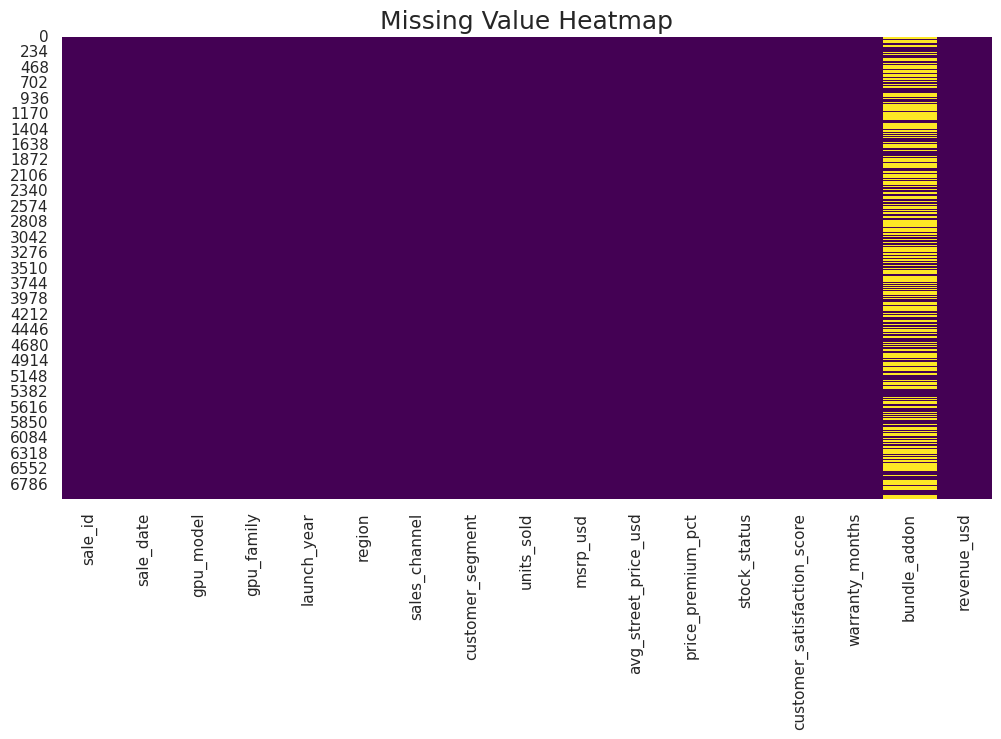

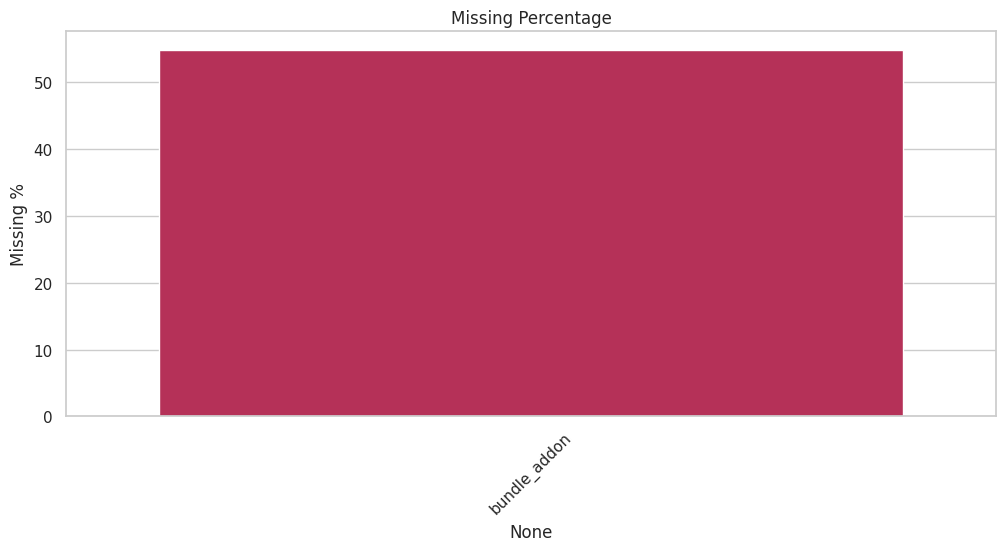

Duplicate Rows : 0
['sale_id', 'launch_year', 'units_sold', 'msrp_usd', 'avg_street_price_usd', 'price_premium_pct', 'customer_satisfaction_score', 'warranty_months', 'revenue_usd']
['gpu_model', 'gpu_family', 'region', 'sales_channel', 'customer_segment', 'stock_status', 'bundle_addon']


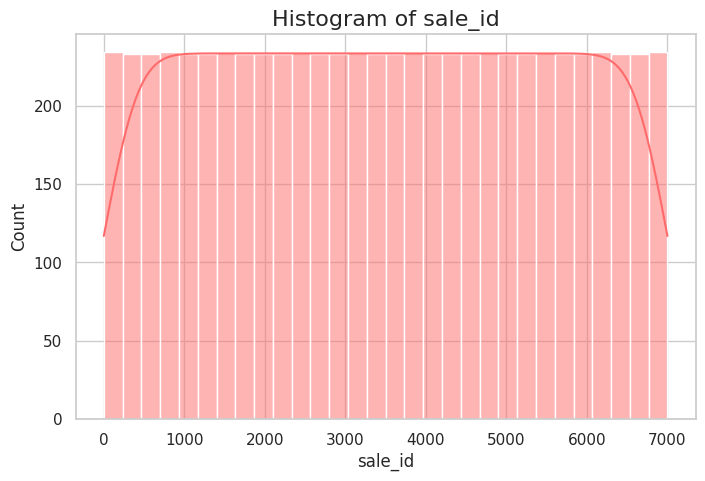

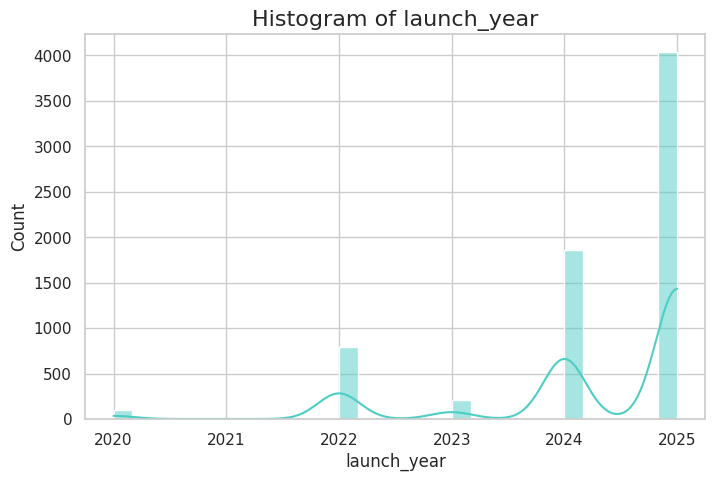

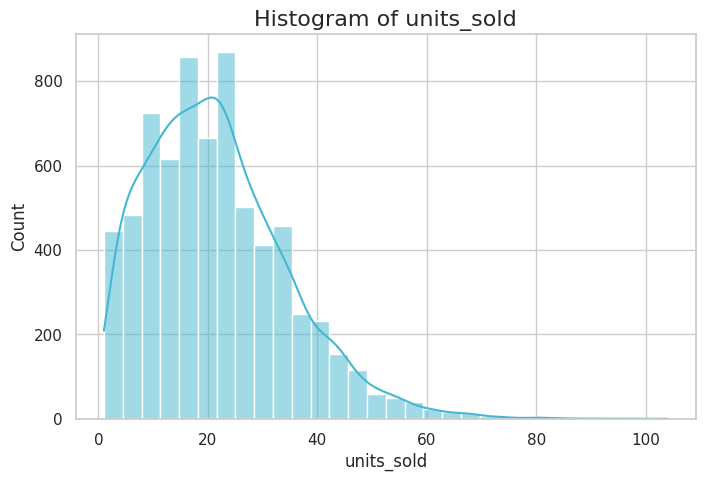

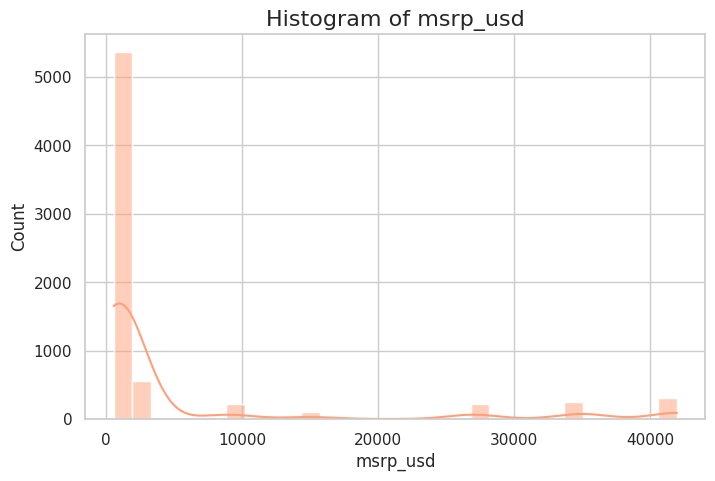

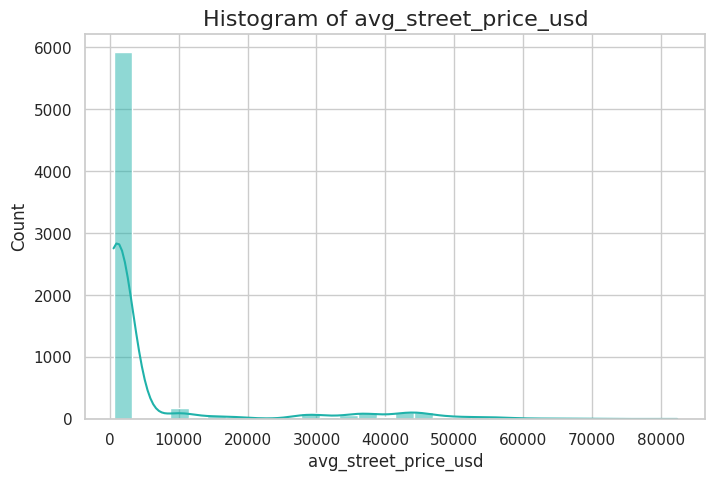

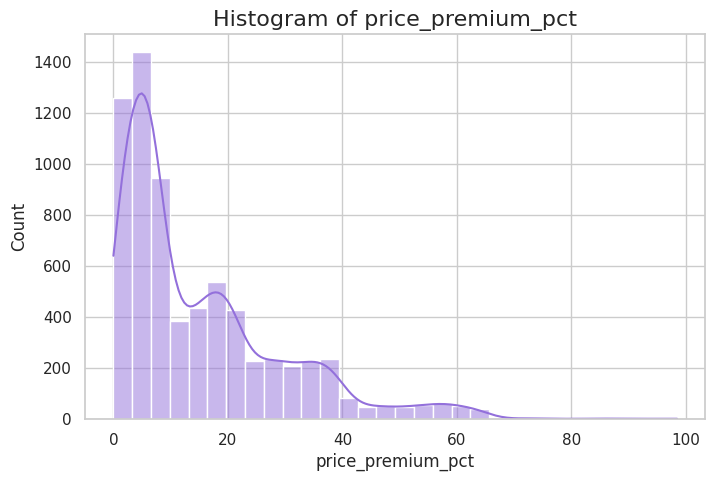

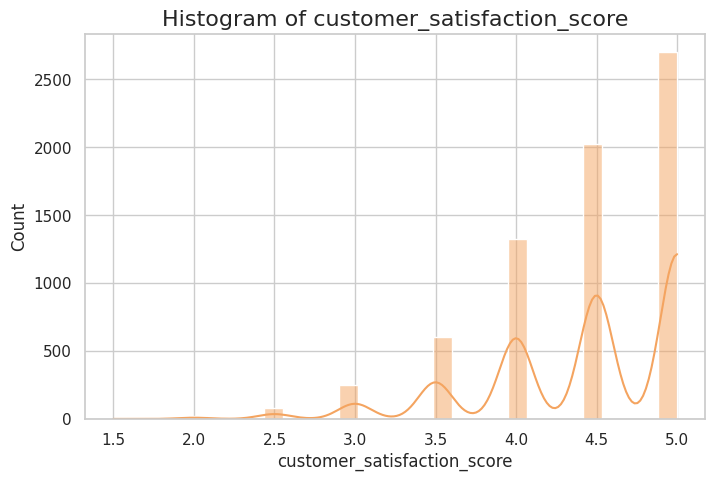

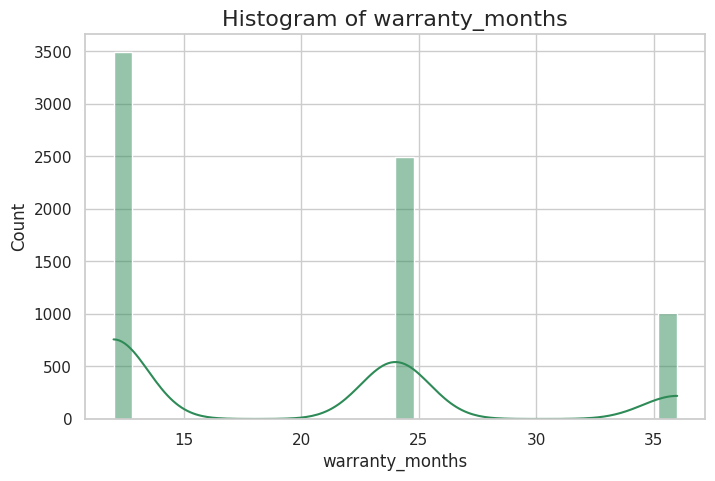

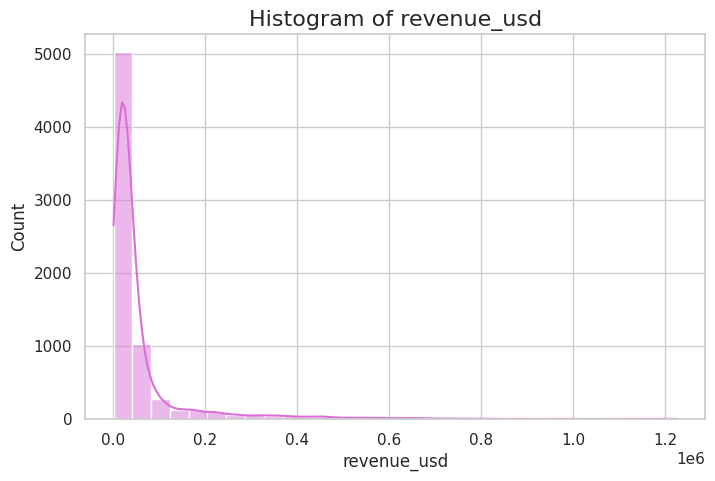

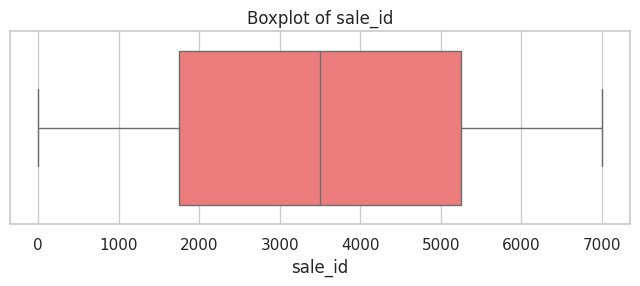

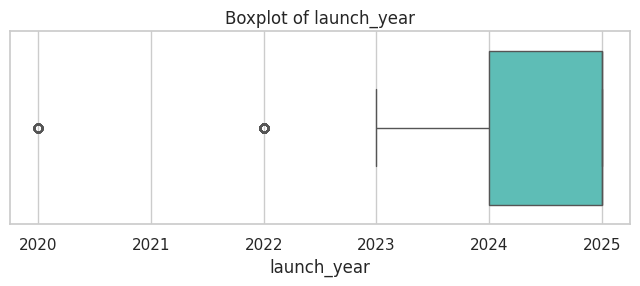

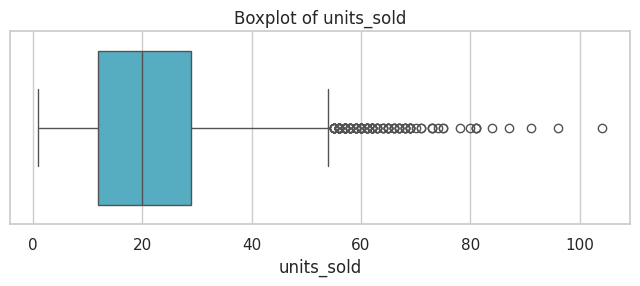

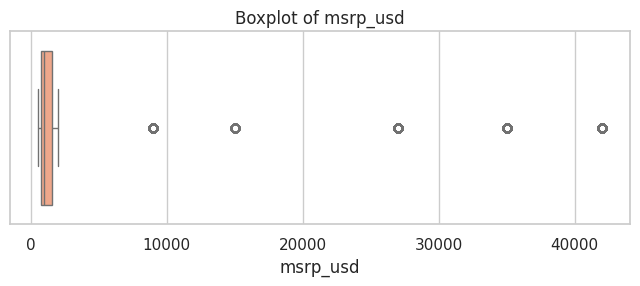

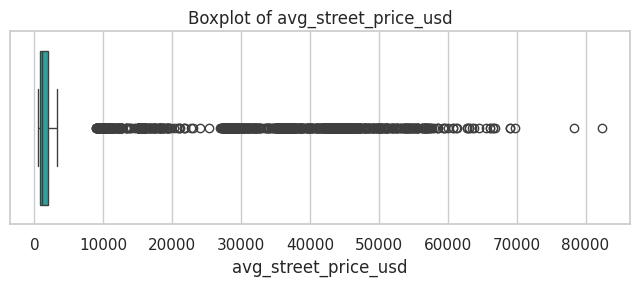

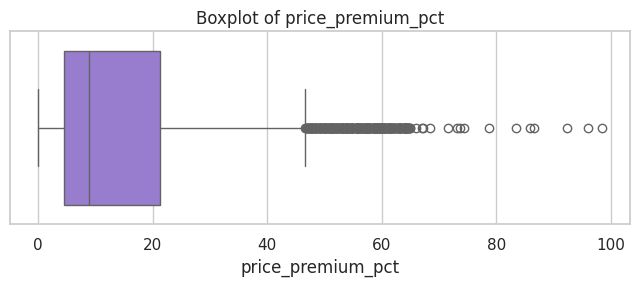

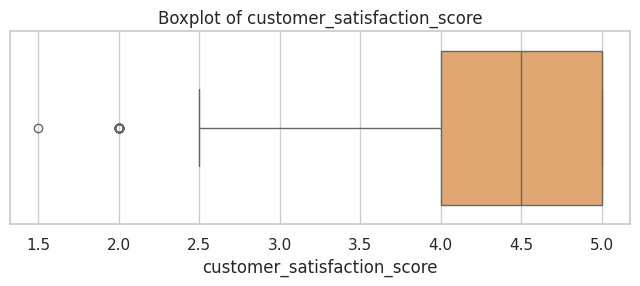

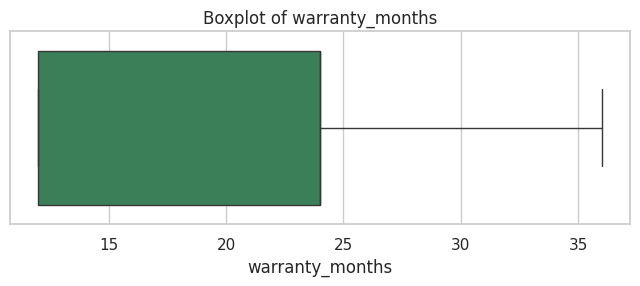

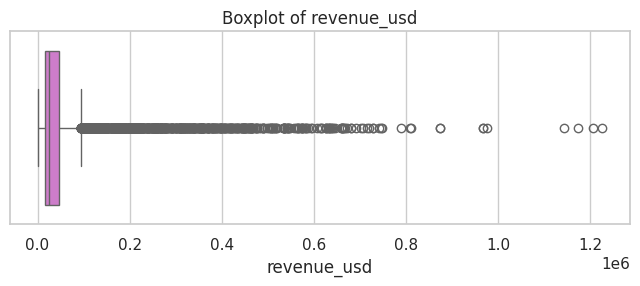

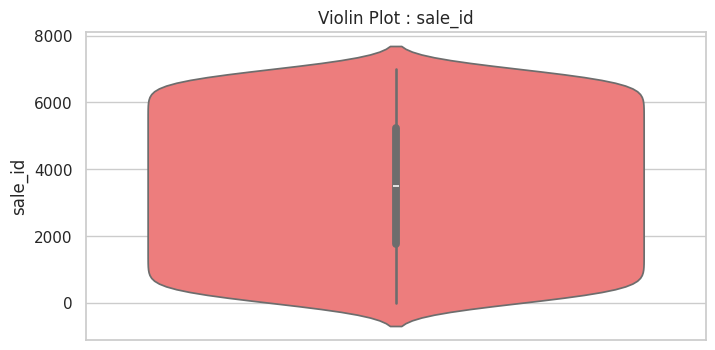

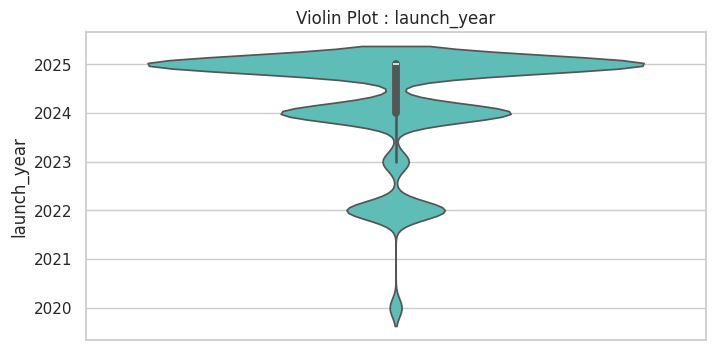

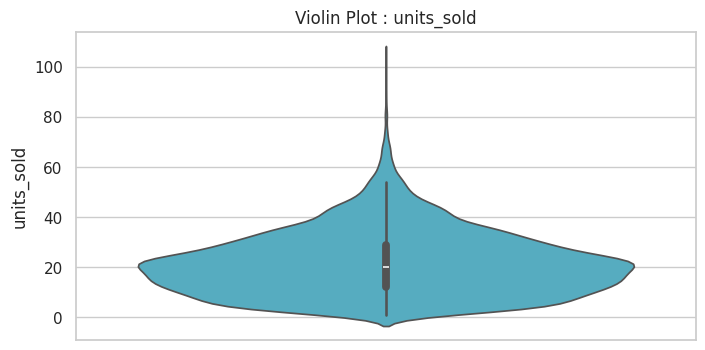

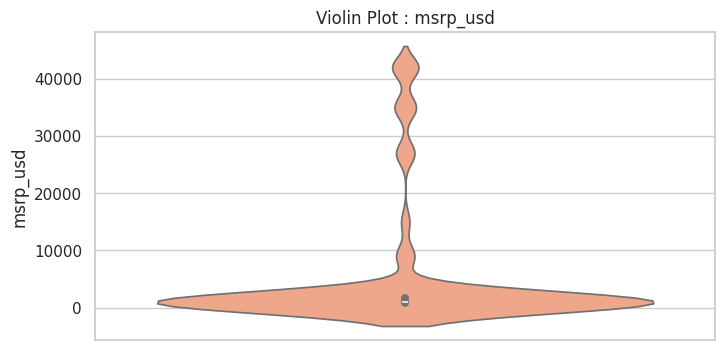

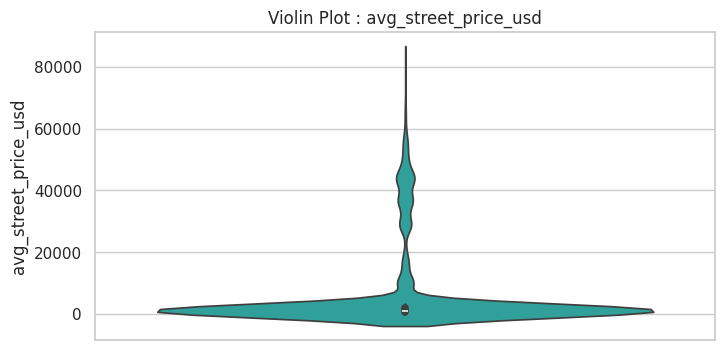

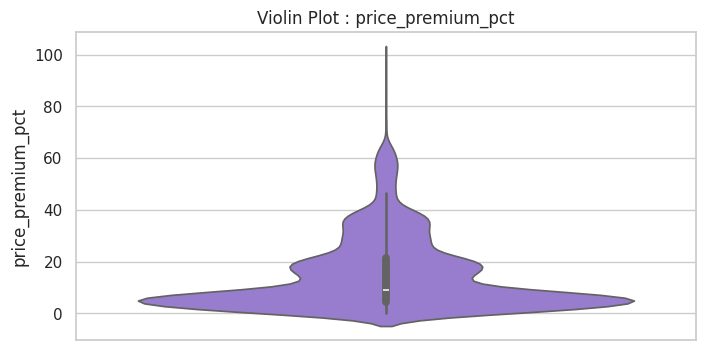

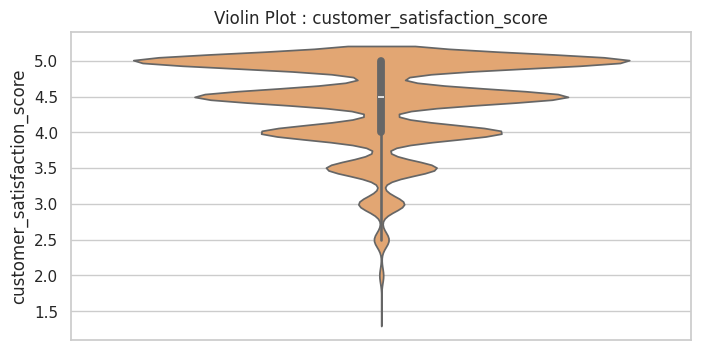

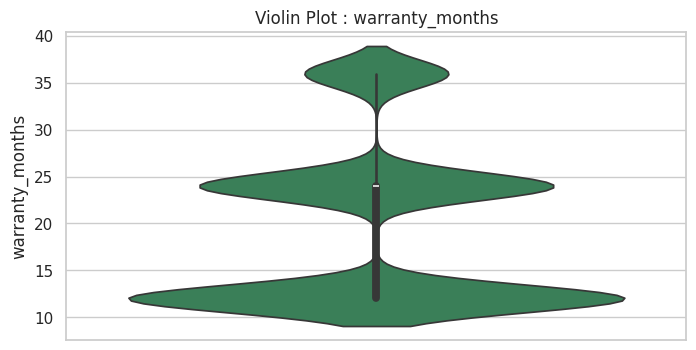

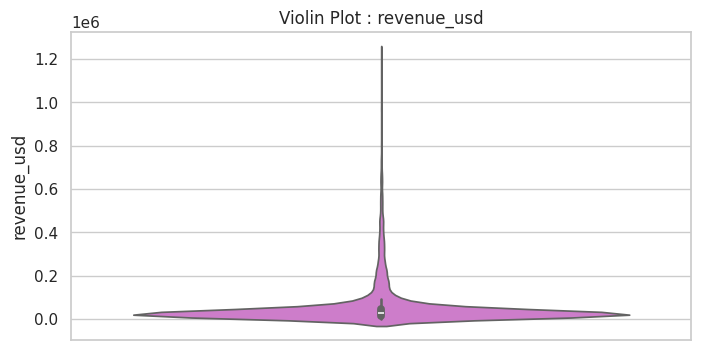

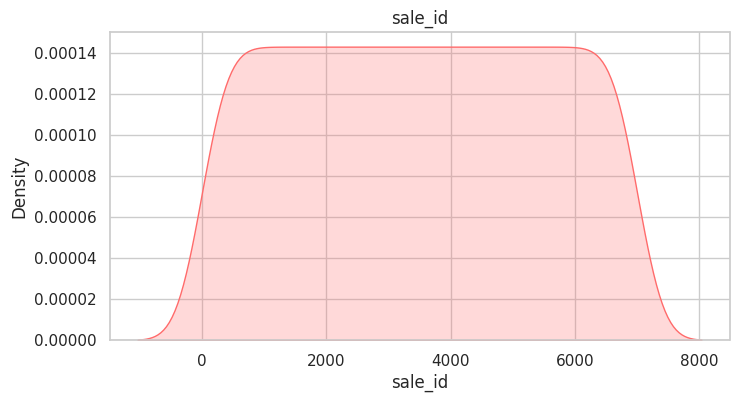

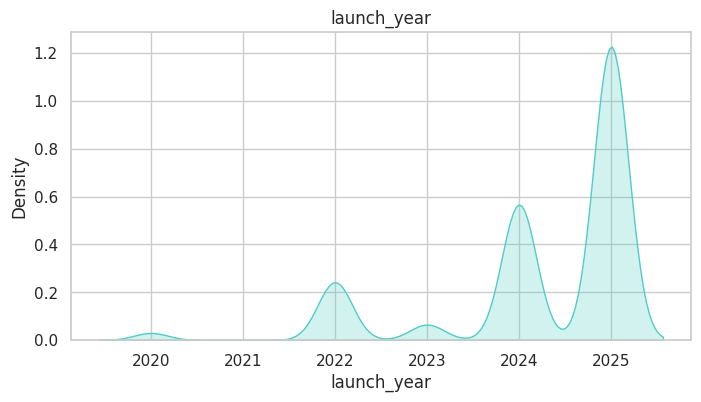

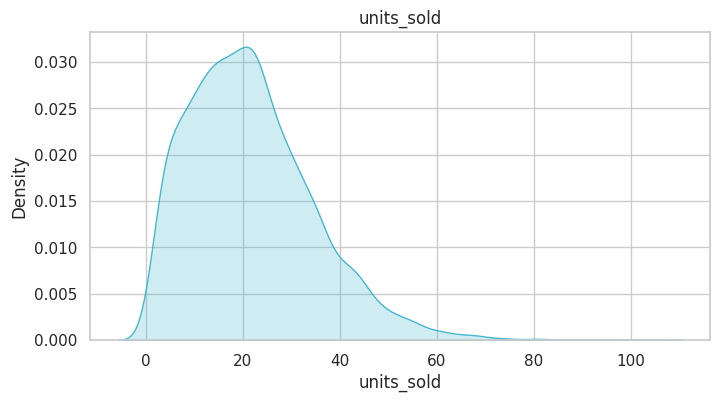

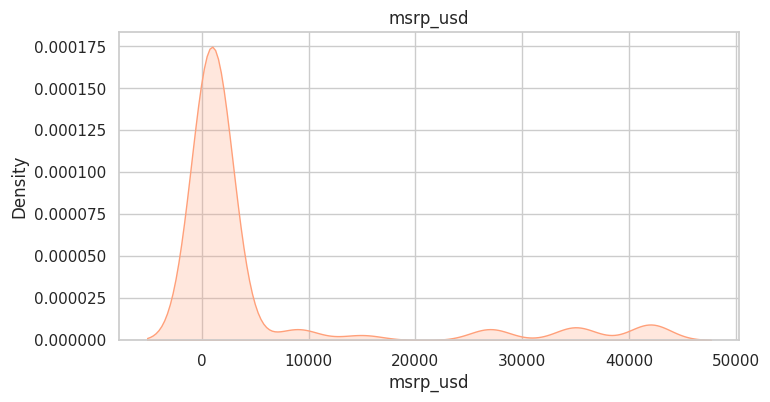

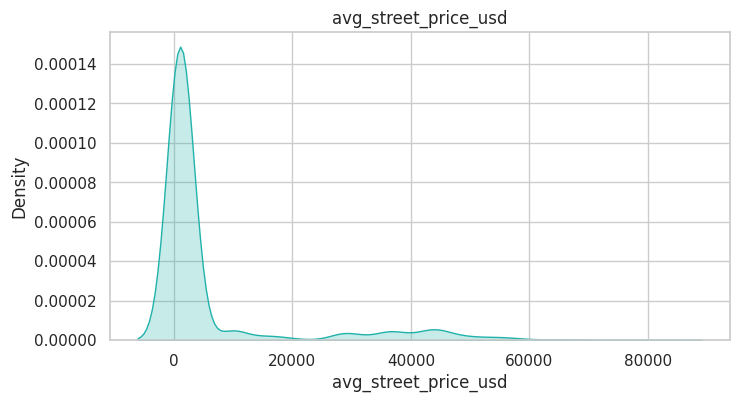

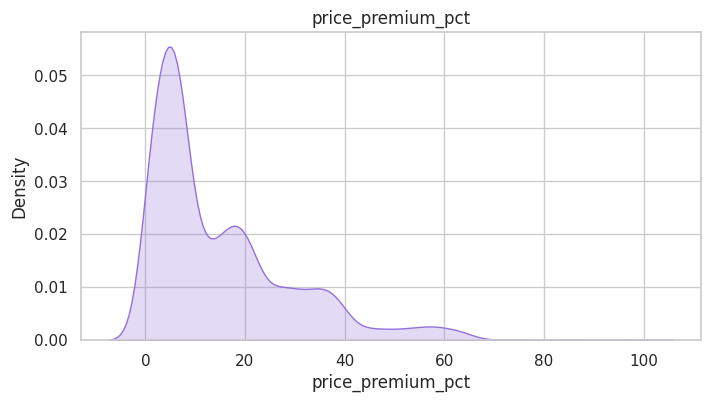

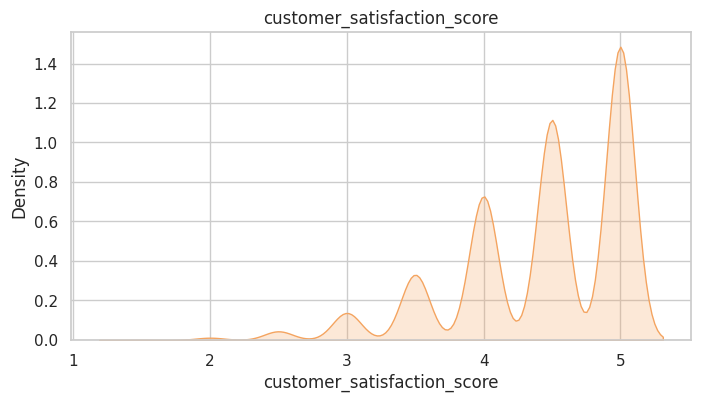

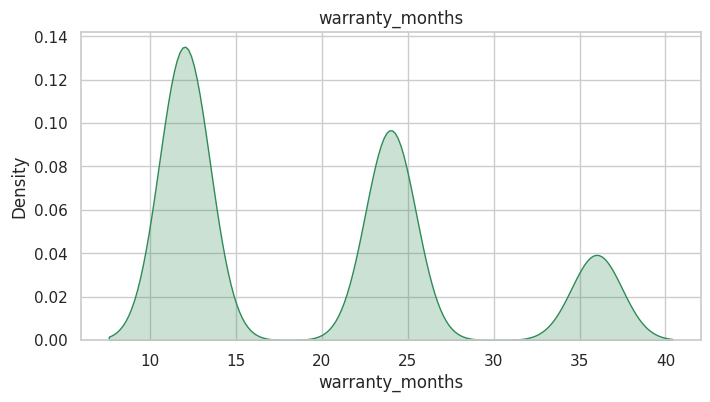

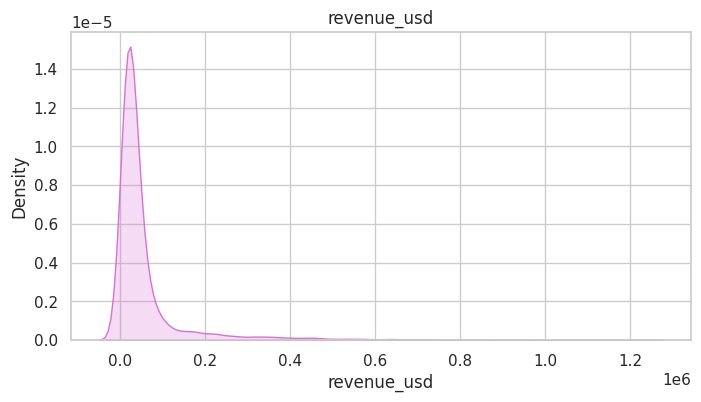

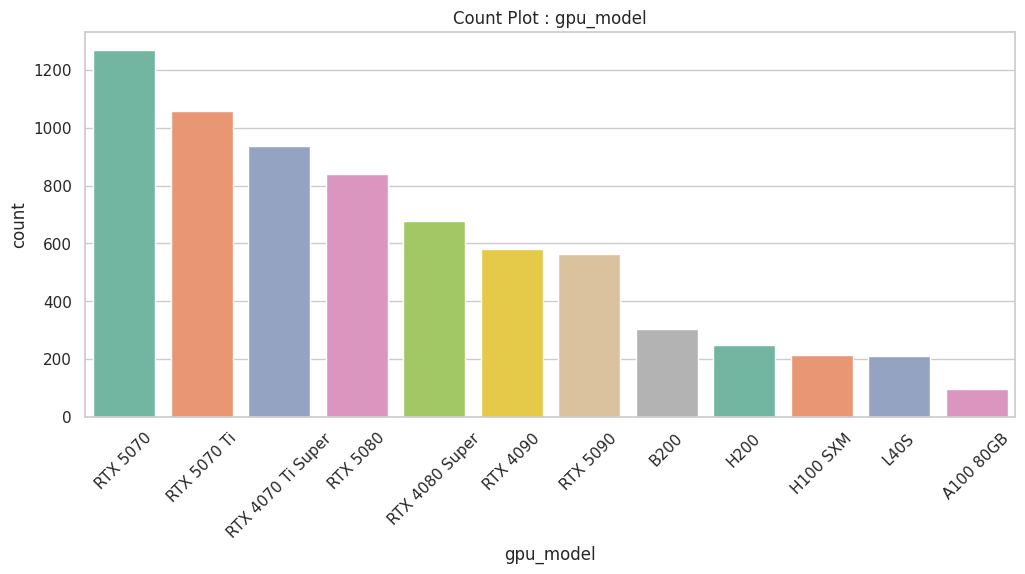

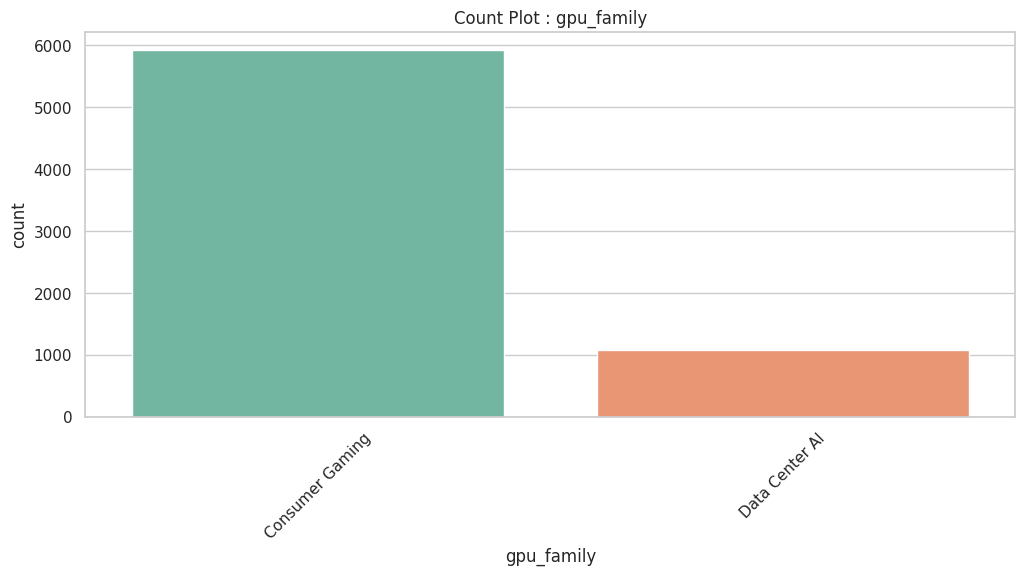

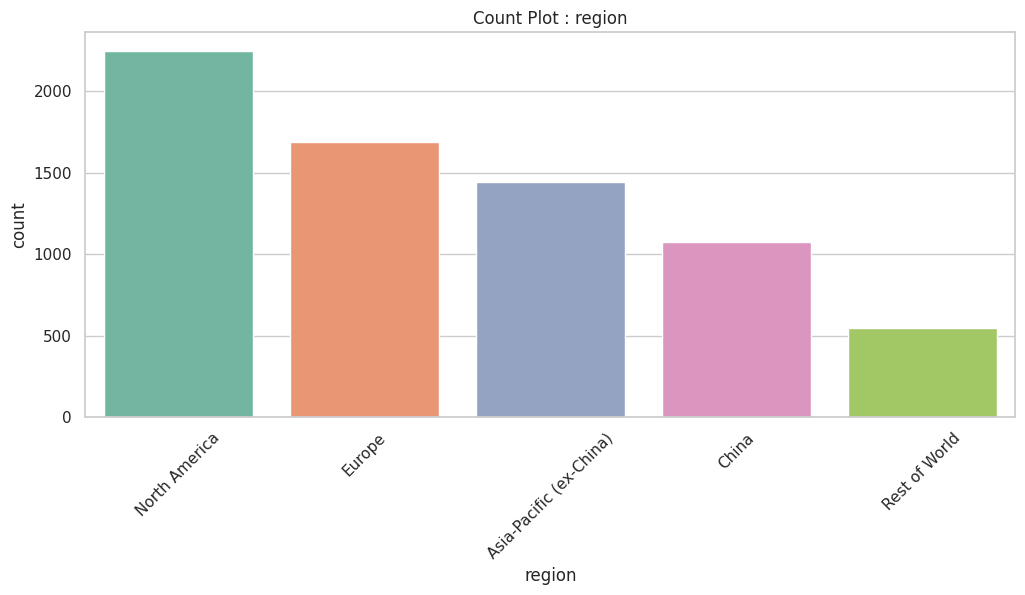

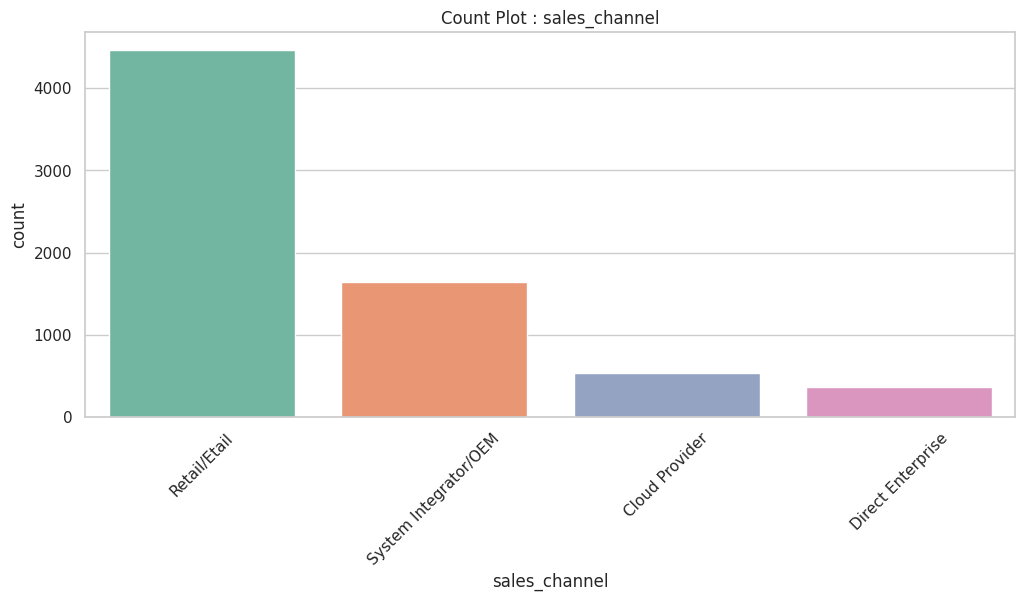

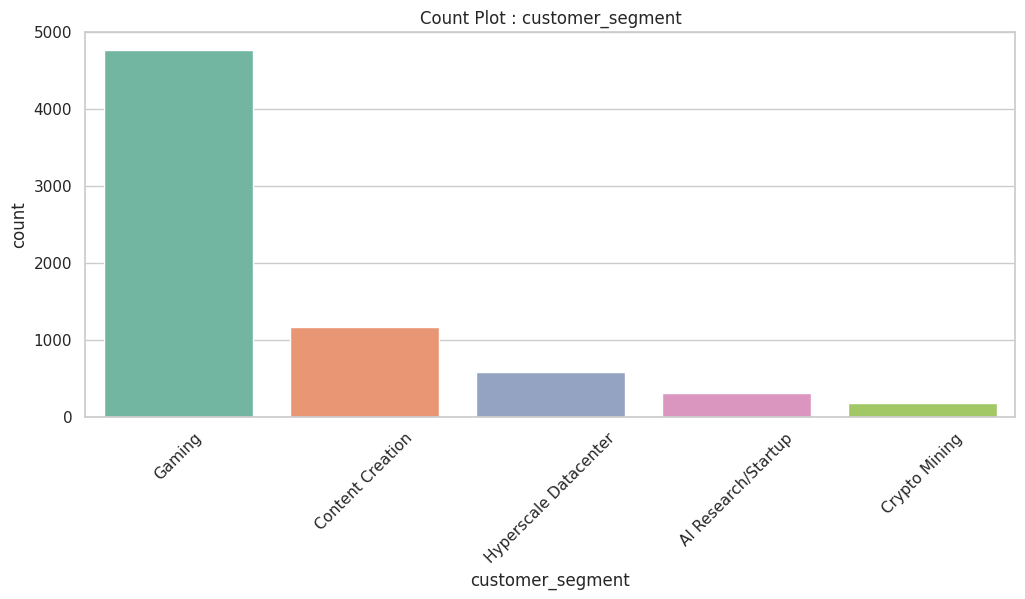

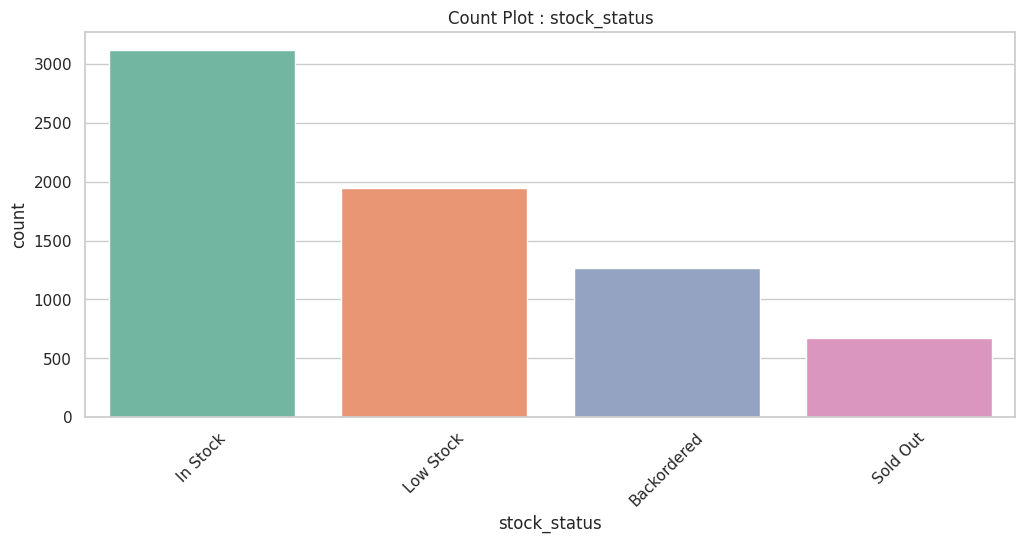

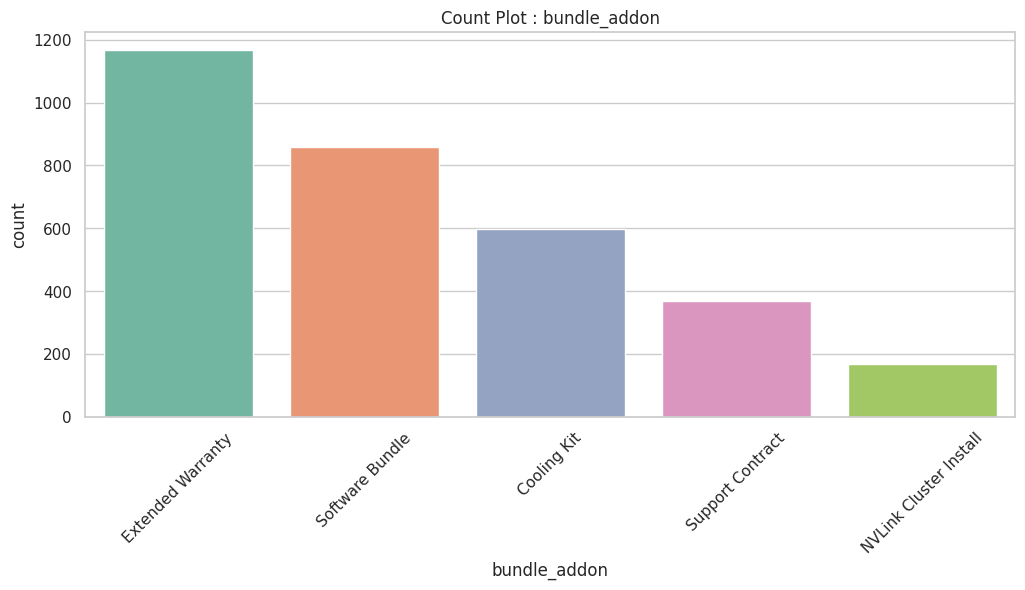

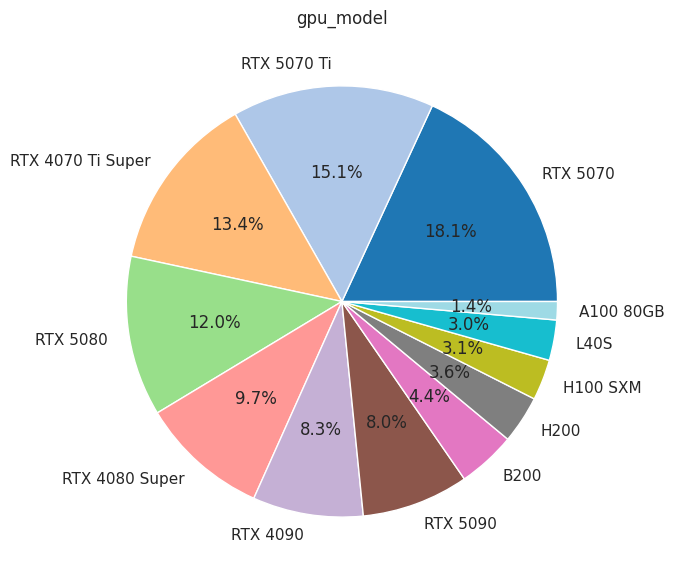

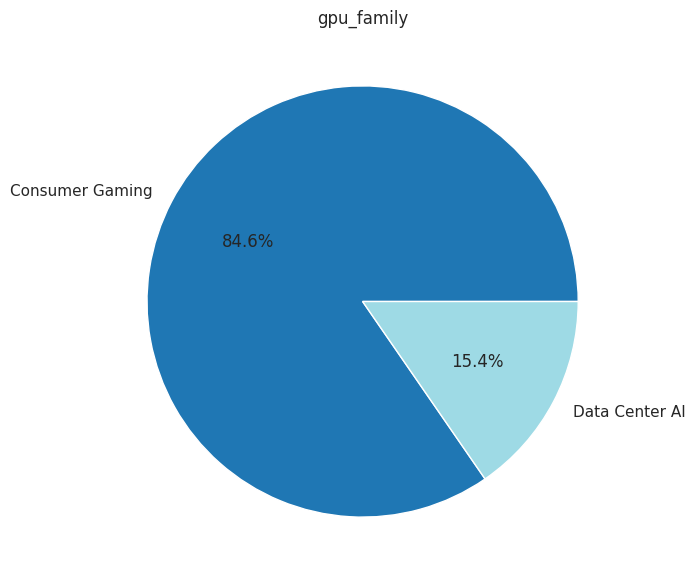

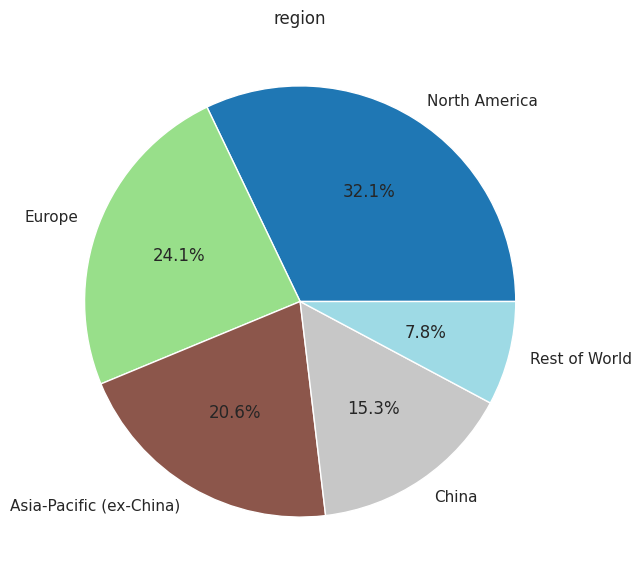

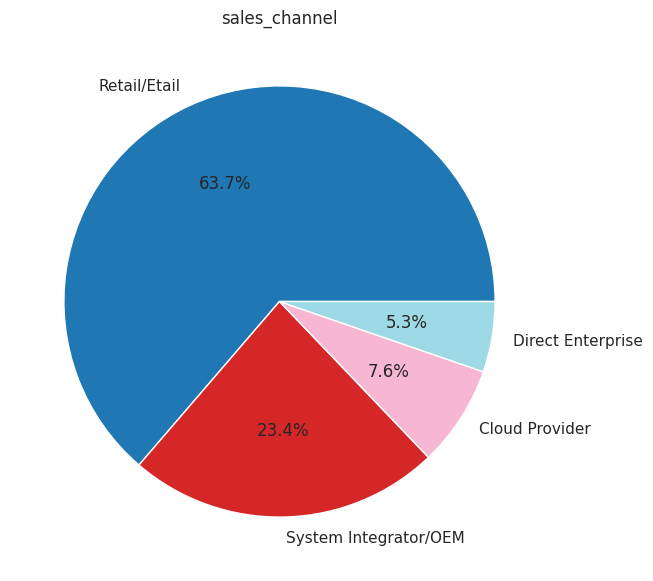

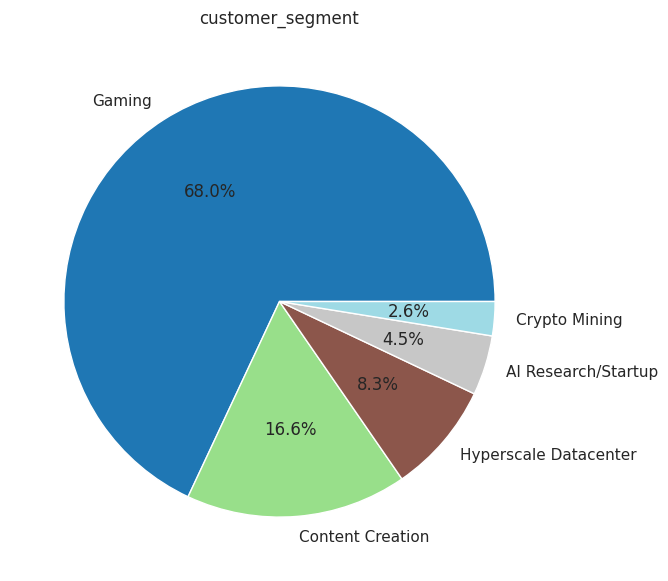

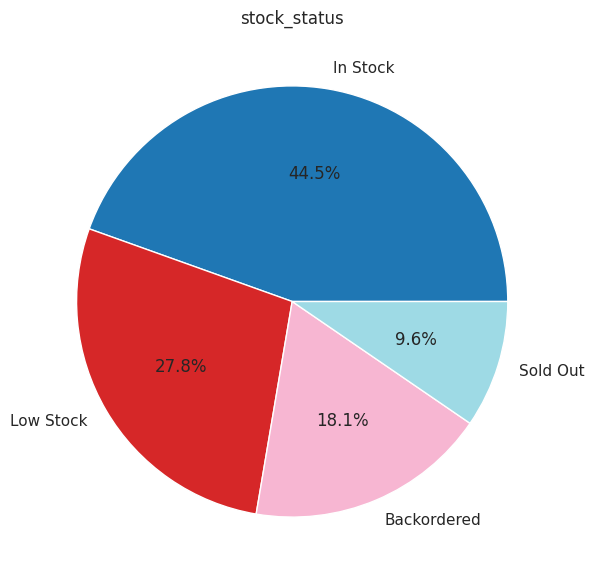

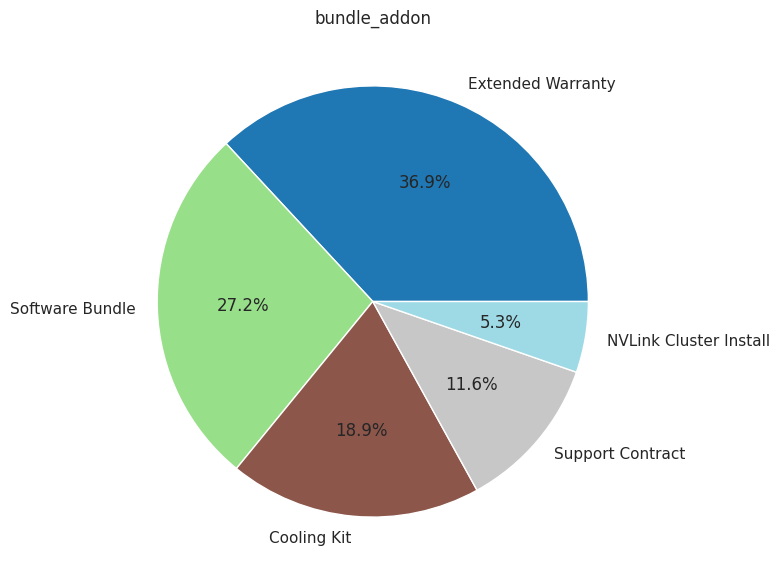

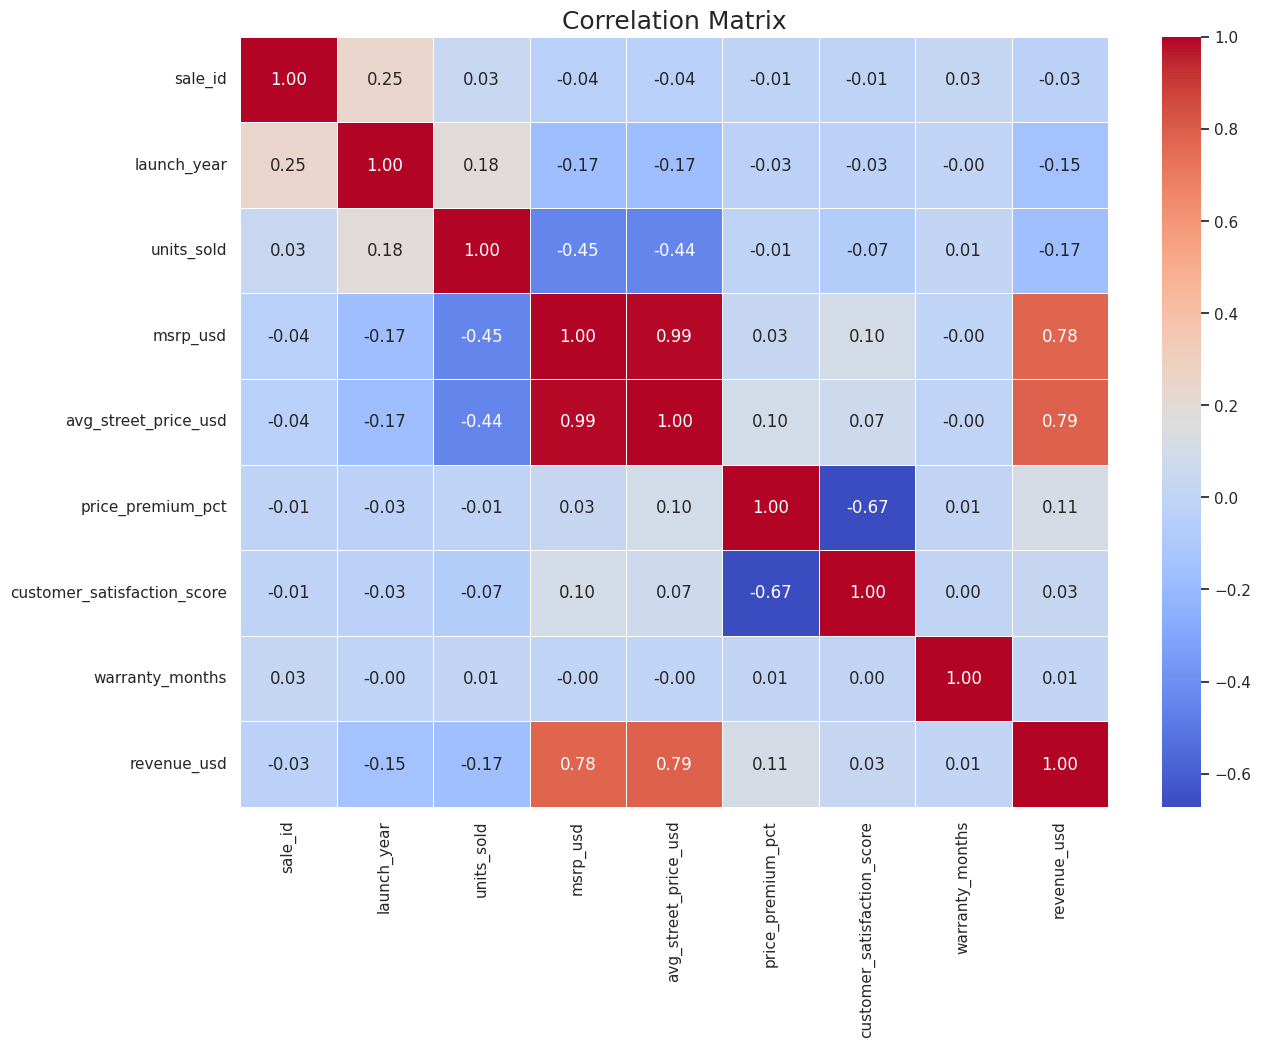

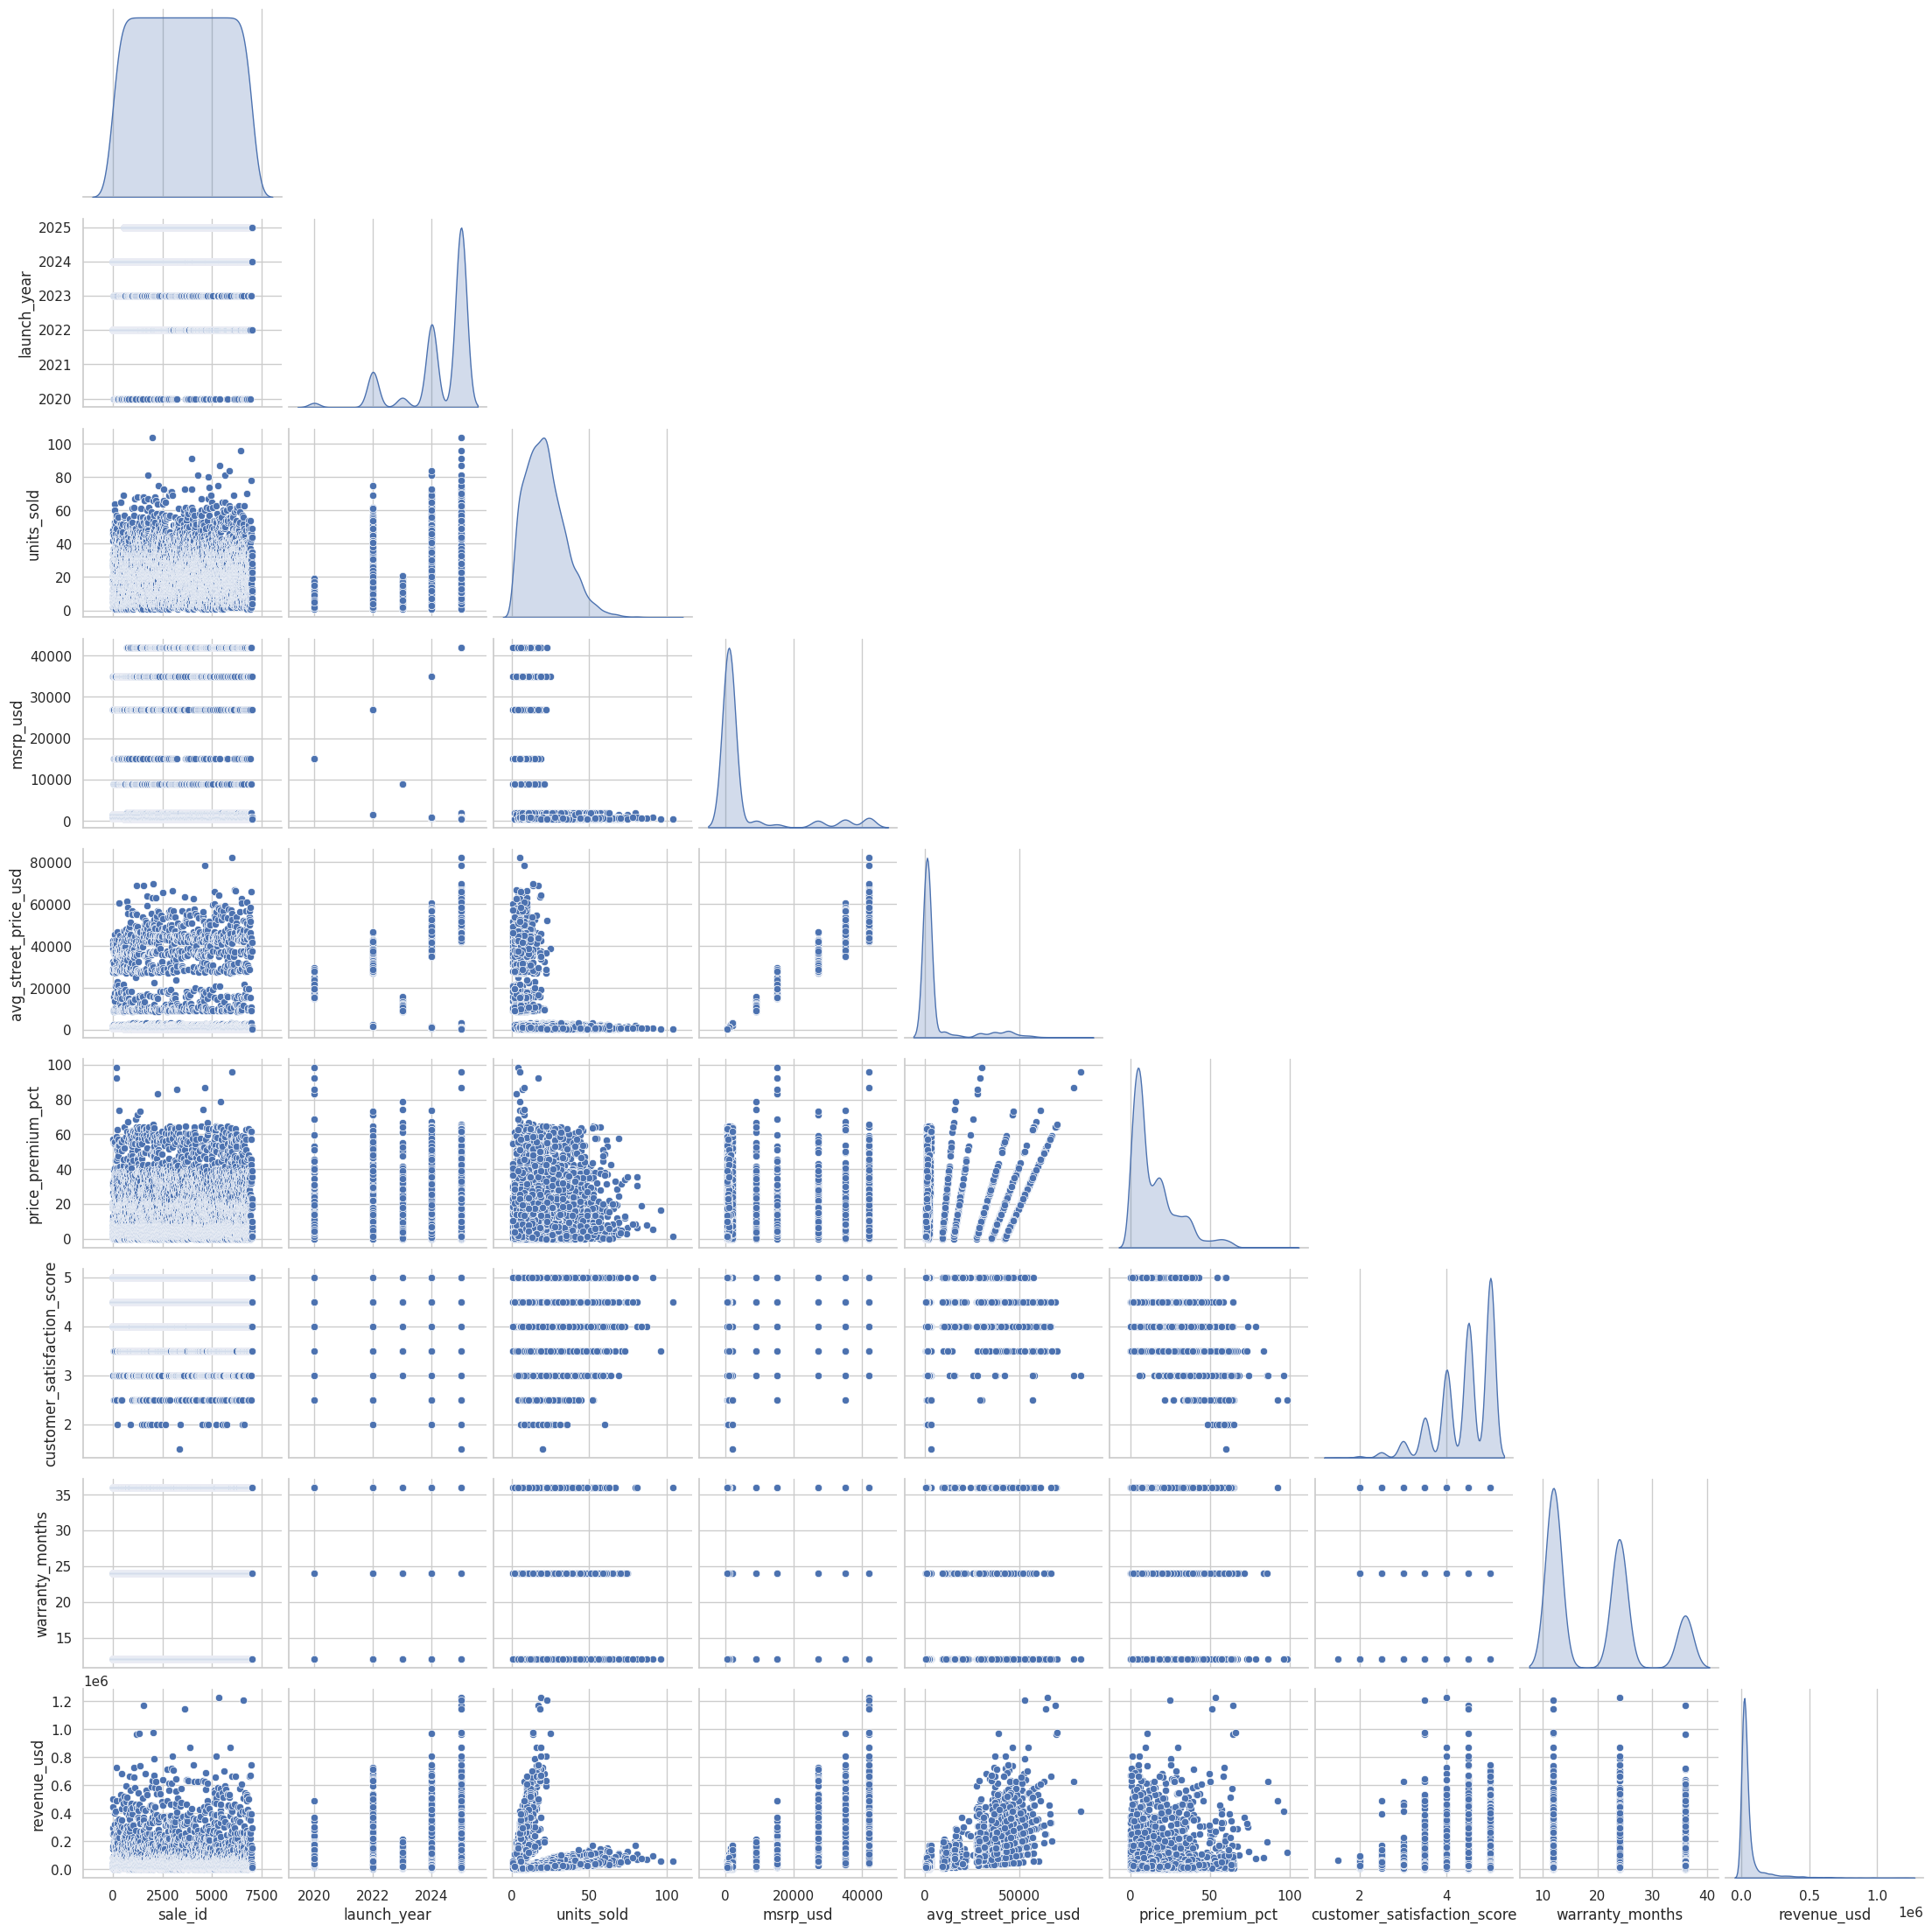

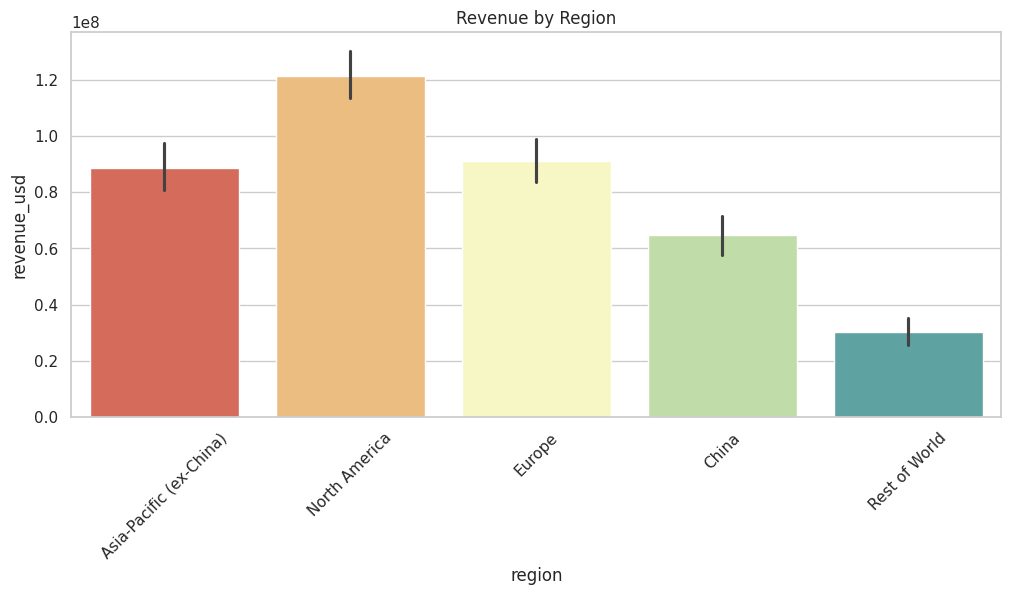

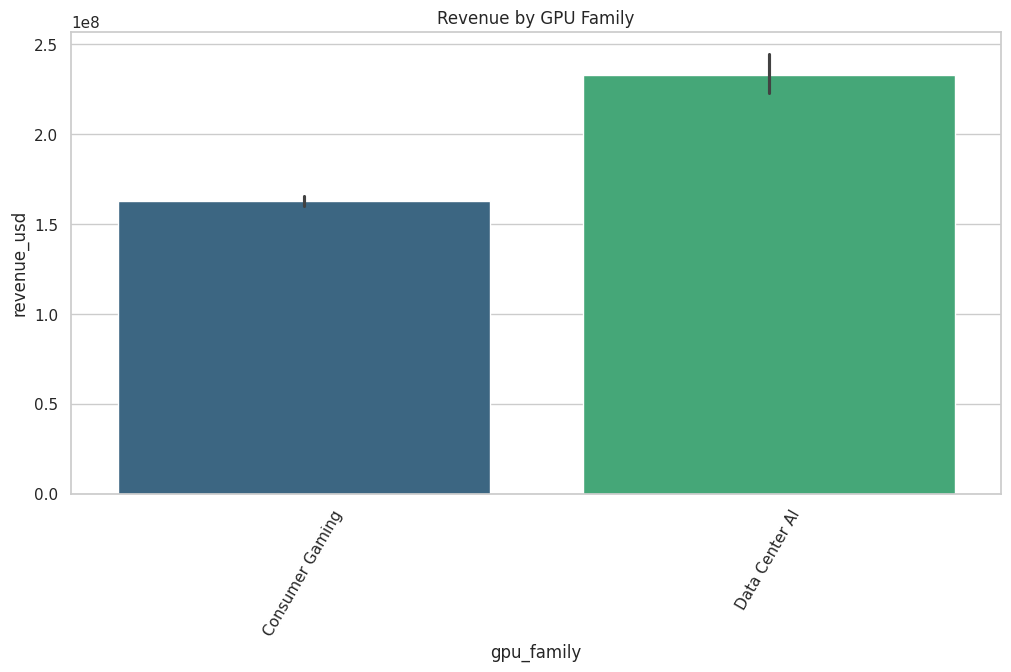

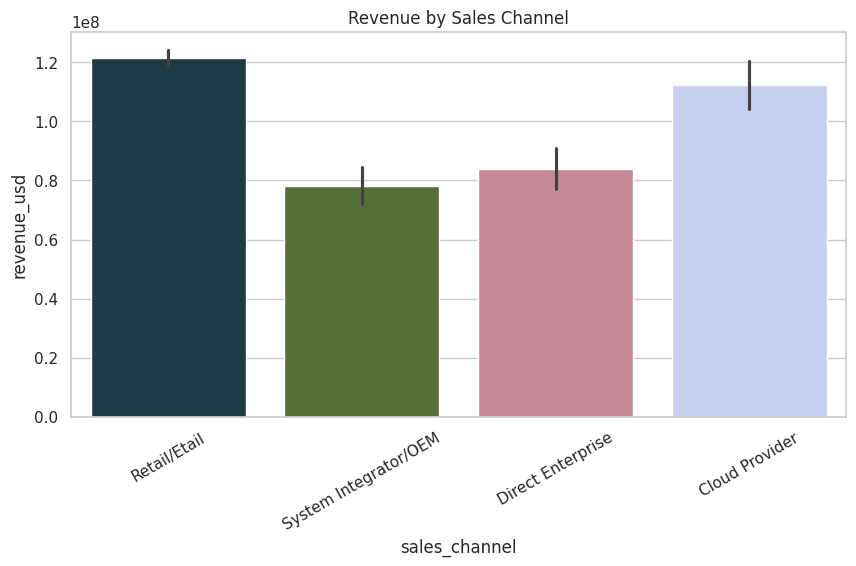

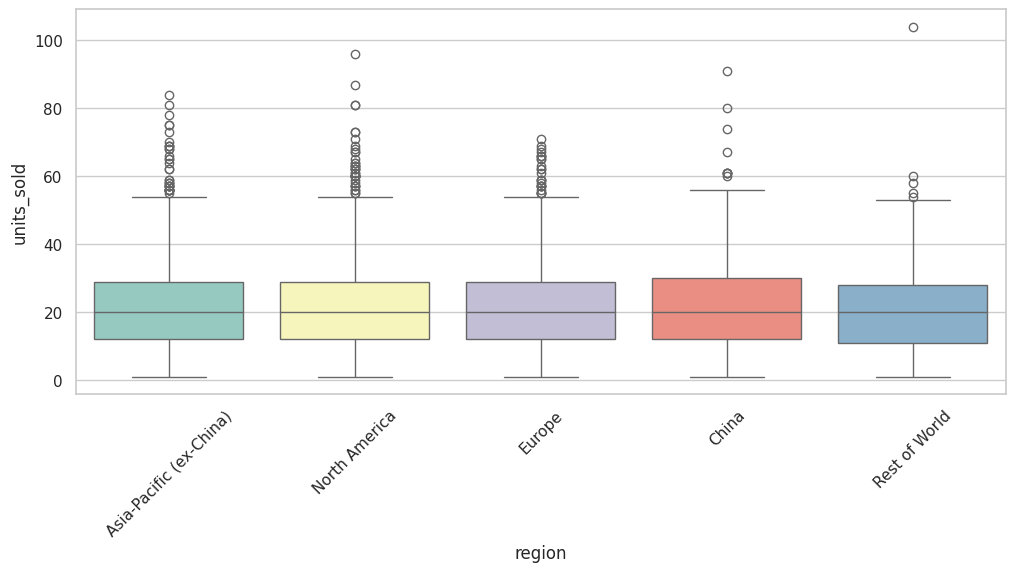

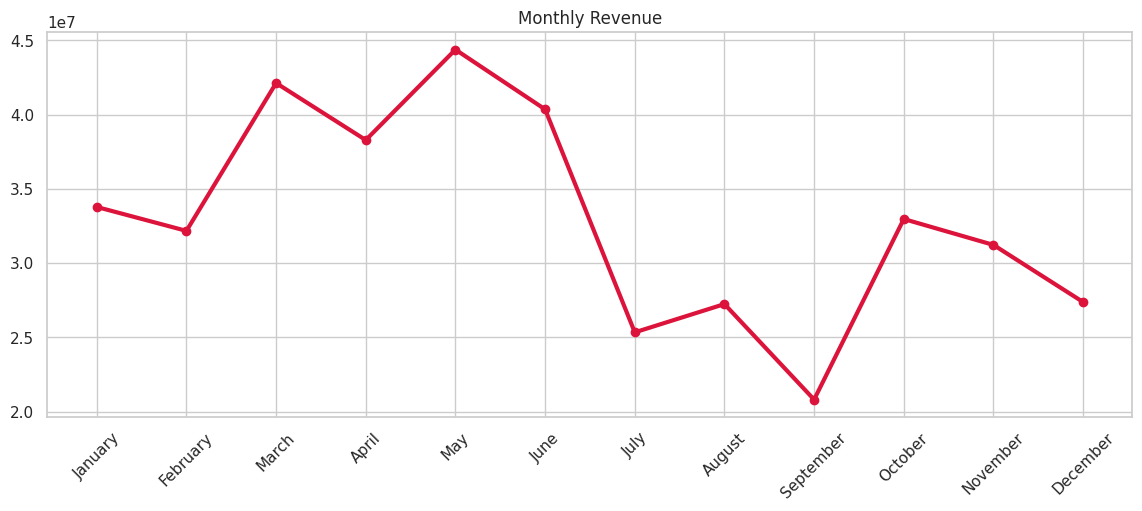

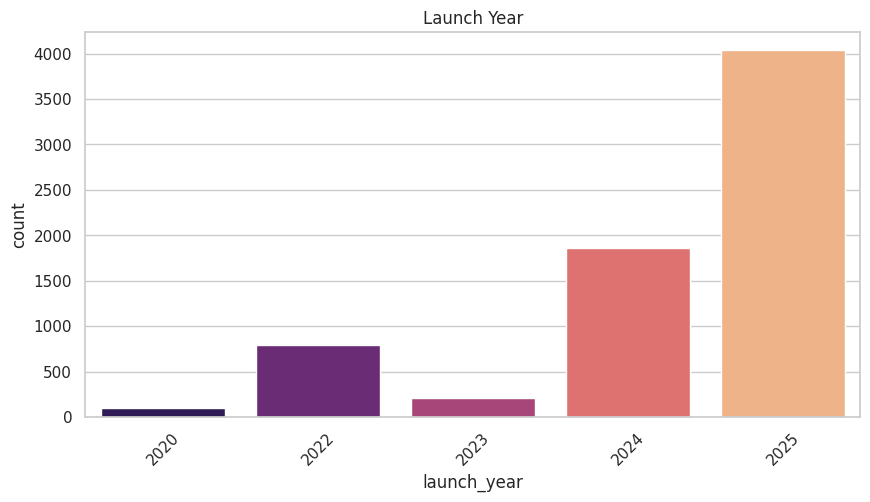

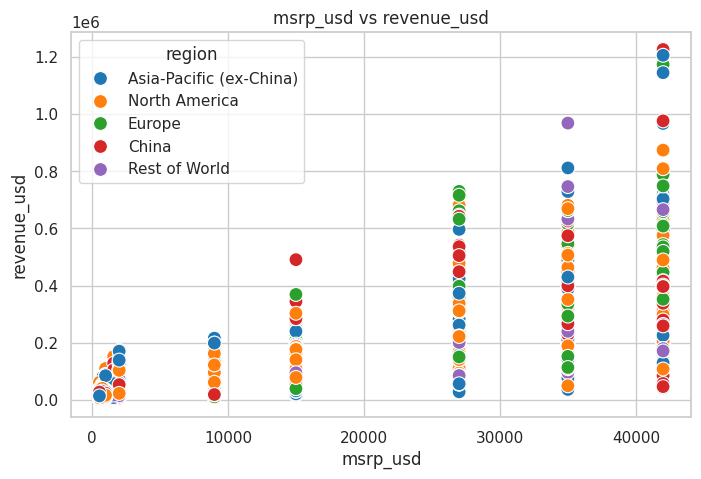

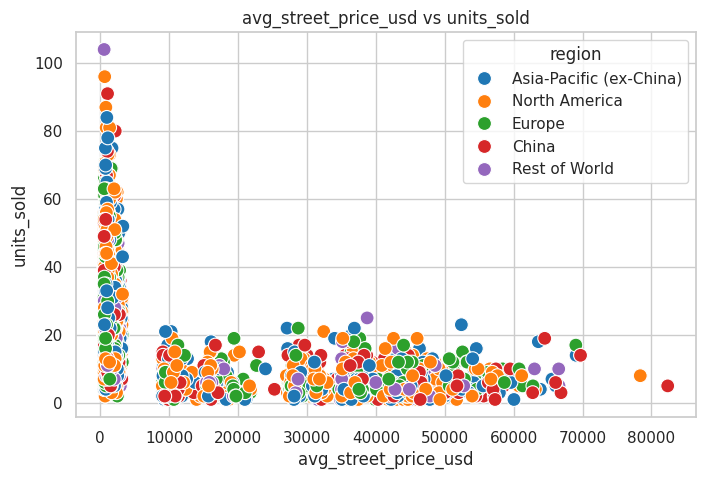

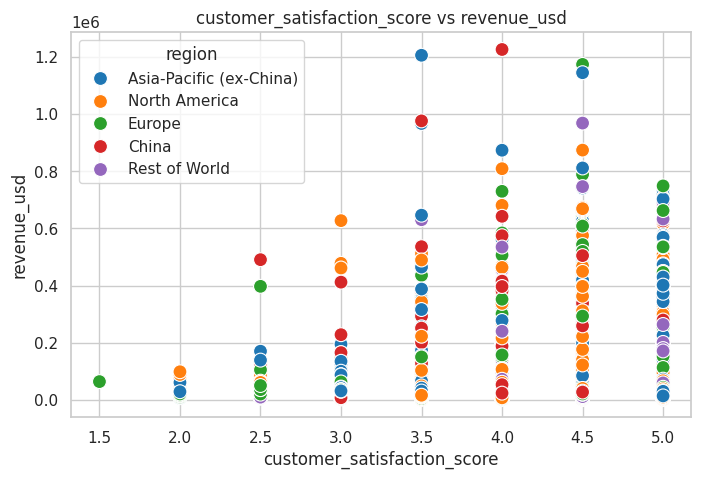

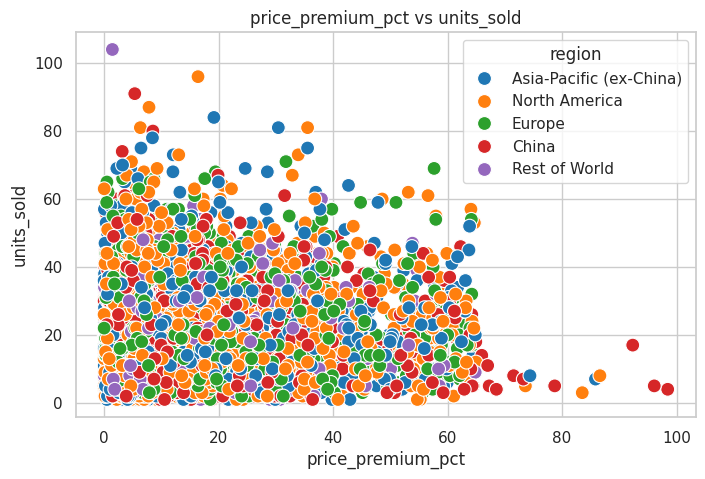

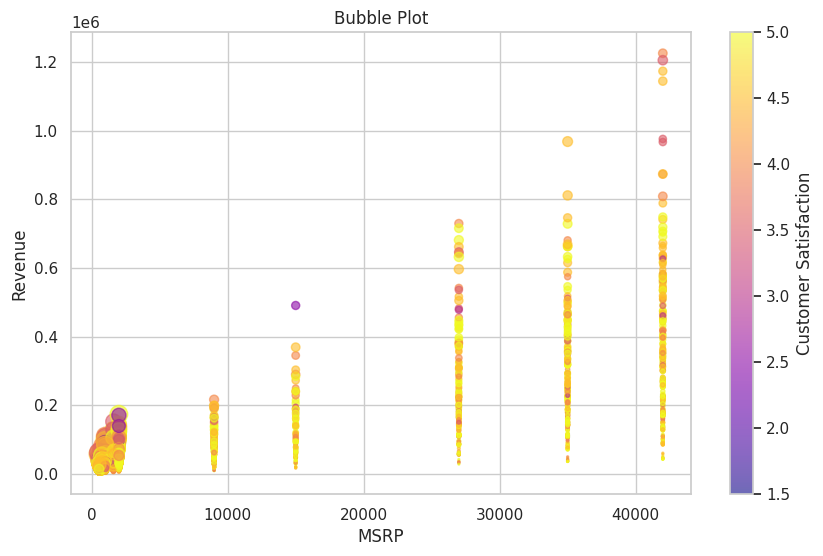

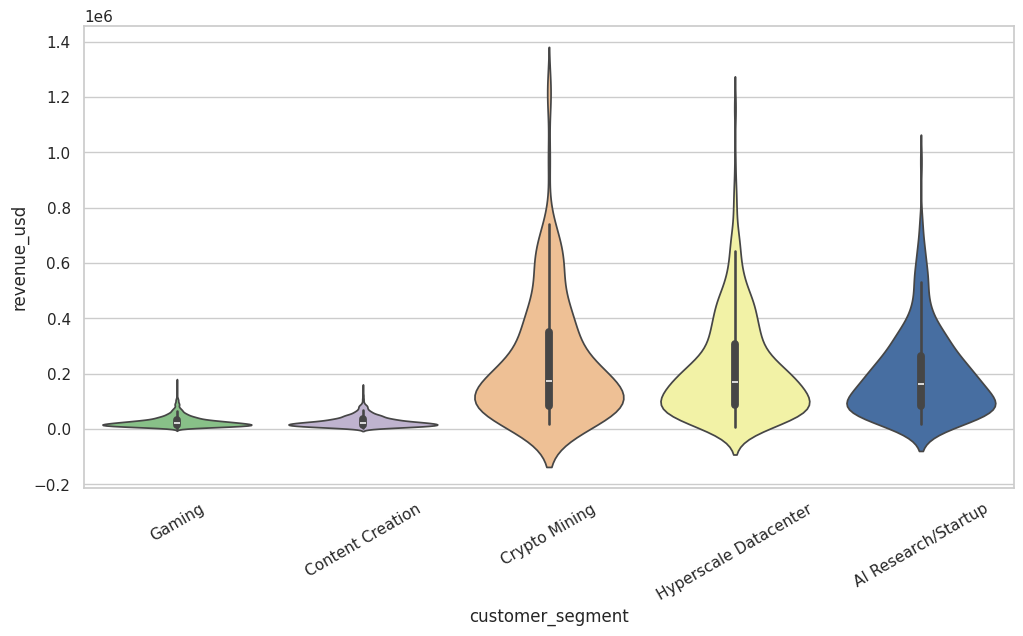

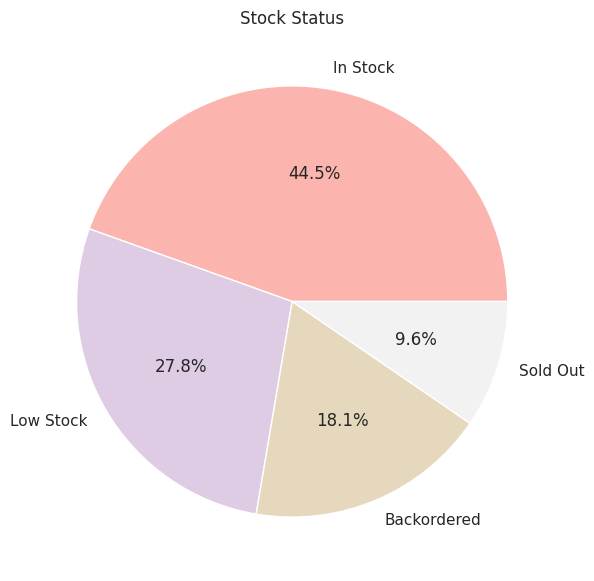

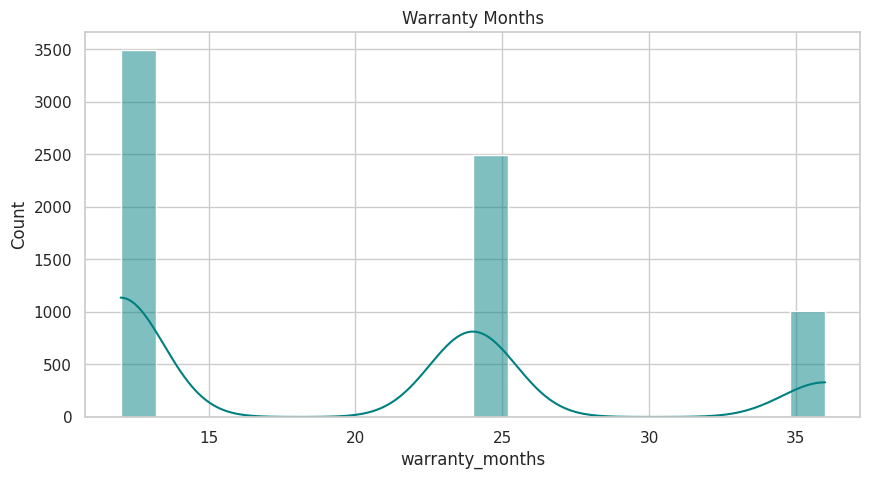

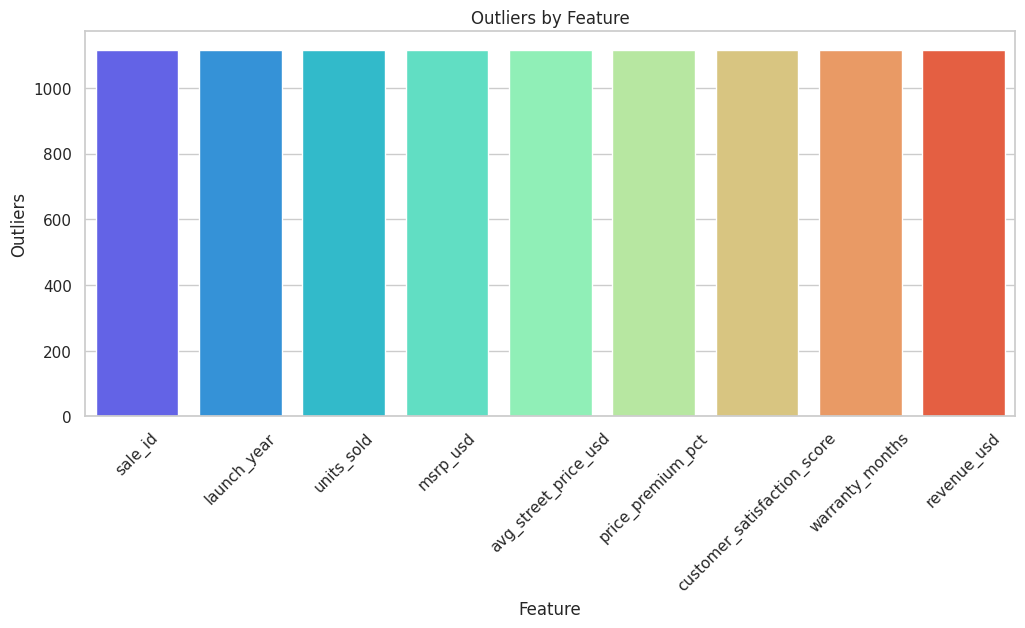

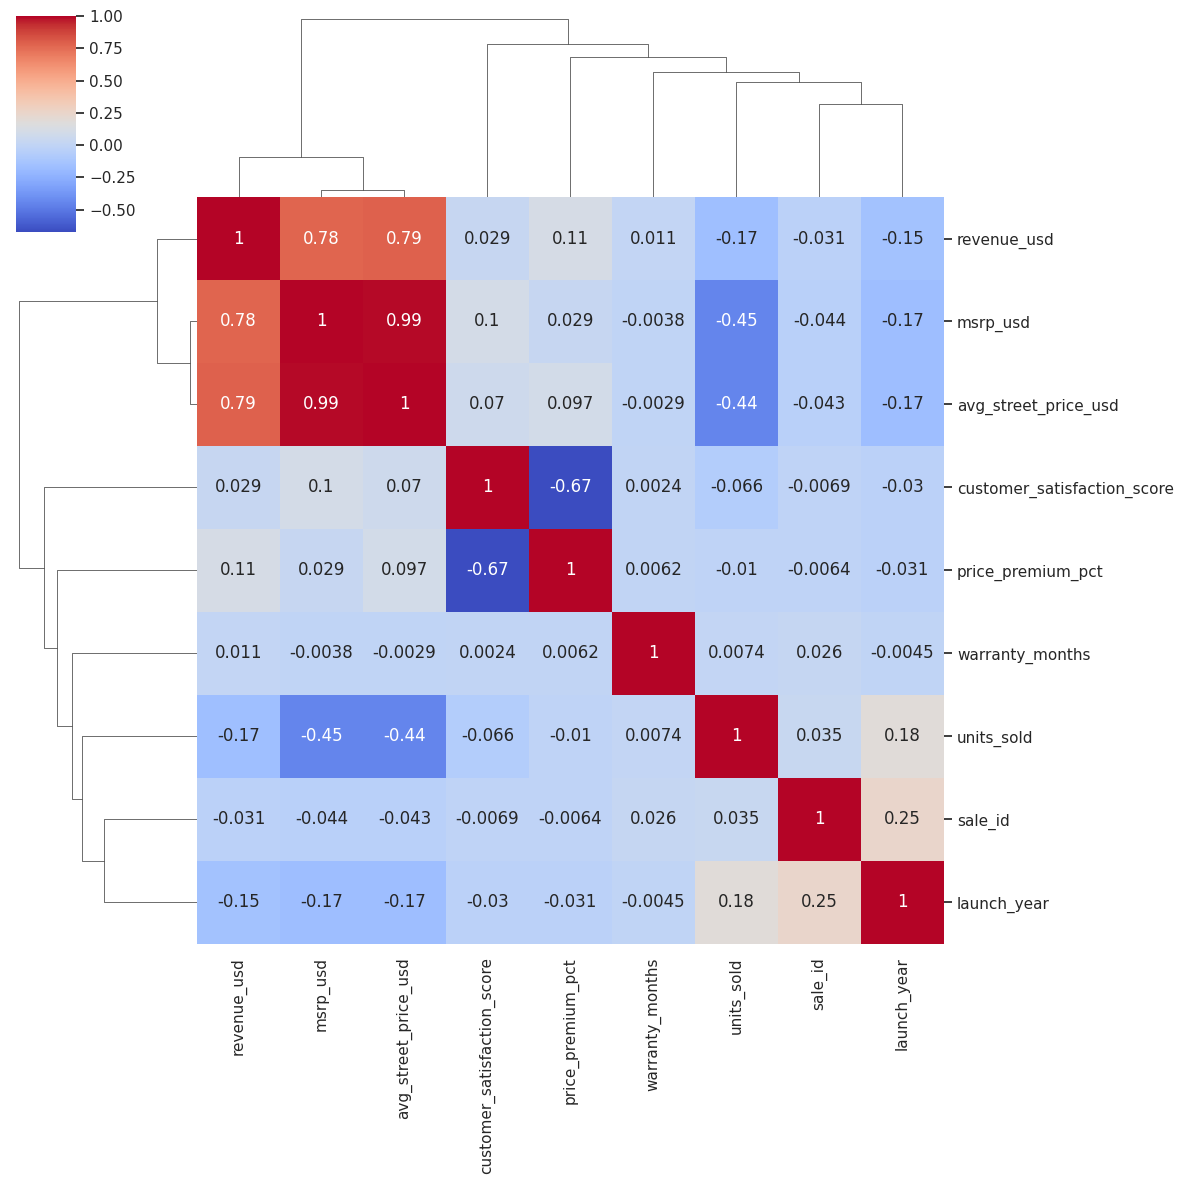

EDA Visualization Completed Successfully


In [14]:
from scipy.stats import zscore


# df = pd.read_csv("train.csv")

# Convert Date
df['sale_date'] = pd.to_datetime(df['sale_date'])

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

colors = [
    "#FF6B6B",
    "#4ECDC4",
    "#45B7D1",
    "#FFA07A",
    "#20B2AA",
    "#9370DB",
    "#F4A460",
    "#2E8B57",
    "#DA70D6",
    "#FF8C00",
    "#4682B4",
    "#DC143C"
]

# ============================================================
# Dataset Information
# ============================================================

print("="*70)
print("Shape:", df.shape)
print("="*70)

print(df.info())

print("="*70)
print(df.describe(include='all'))

# ============================================================
# Missing Values
# ============================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap",fontsize=18)
plt.show()

# Missing Percentage

missing=df.isnull().sum()/len(df)*100
missing=missing[missing>0].sort_values(ascending=False)

if len(missing)>0:

    plt.figure(figsize=(12,5))

    sns.barplot(
        x=missing.index,
        y=missing.values,
        palette="rocket"
    )

    plt.xticks(rotation=45)

    plt.ylabel("Missing %")

    plt.title("Missing Percentage")

    plt.show()

# ============================================================
# Duplicate Values
# ============================================================

print("Duplicate Rows :",df.duplicated().sum())

# ============================================================
# Numerical Columns
# ============================================================

num_cols=df.select_dtypes(include=np.number).columns.tolist()

print(num_cols)

# ============================================================
# Categorical Columns
# ============================================================

cat_cols=df.select_dtypes(include="object").columns.tolist()

print(cat_cols)

# ============================================================
# Date Features
# ============================================================

df["Year"]=df.sale_date.dt.year
df["Month"]=df.sale_date.dt.month_name()
df["Quarter"]=df.sale_date.dt.quarter
df["Day"]=df.sale_date.dt.day_name()

# ============================================================
# Histograms
# ============================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True,
        color=colors[i%len(colors)],
        bins=30
    )

    plt.title(f"Histogram of {col}",fontsize=16)

    plt.show()

# ============================================================
# Boxplots
# ============================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,2.5))

    sns.boxplot(
        x=df[col],
        color=colors[i%len(colors)]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

# ============================================================
# Violin Plots
# ============================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.violinplot(
        y=df[col],
        color=colors[i%len(colors)]
    )

    plt.title(f"Violin Plot : {col}")

    plt.show()

# ============================================================
# Distribution Plot
# ============================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        df[col],
        shade=True,
        color=colors[i%len(colors)]
    )

    plt.title(col)

    plt.show()

# ============================================================
# Countplots
# ============================================================

for i,col in enumerate(cat_cols):

    plt.figure(figsize=(12,5))

    order=df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order,
        palette="Set2"
    )

    plt.xticks(rotation=45)

    plt.title(f"Count Plot : {col}")

    plt.show()

# ============================================================
# Pie Charts
# ============================================================

for col in cat_cols:

    plt.figure(figsize=(7,7))

    df[col].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        cmap="tab20"
    )

    plt.ylabel("")

    plt.title(col)

    plt.show()

# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(14,10))

corr=df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidth=.5
)

plt.title("Correlation Matrix",fontsize=18)

plt.show()

# ============================================================
# Pairplot
# ============================================================

sns.pairplot(
    df[num_cols],
    corner=True,
    diag_kind="kde"
)

plt.show()

# ============================================================
# Revenue by Region
# ============================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x="region",
    y="revenue_usd",
    estimator=np.sum,
    palette="Spectral"
)

plt.xticks(rotation=45)

plt.title("Revenue by Region")

plt.show()

# ============================================================
# Revenue by GPU Family
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="gpu_family",
    y="revenue_usd",
    estimator=np.sum,
    palette="viridis"
)

plt.xticks(rotation=60)

plt.title("Revenue by GPU Family")

plt.show()

# ============================================================
# Revenue by Sales Channel
# ============================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="sales_channel",
    y="revenue_usd",
    estimator=np.sum,
    palette="cubehelix"
)

plt.title("Revenue by Sales Channel")

plt.xticks(rotation=30)

plt.show()

# ============================================================
# Units Sold by Region
# ============================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="region",
    y="units_sold",
    palette="Set3"
)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# Monthly Revenue Trend
# ============================================================

monthly=df.groupby("Month")["revenue_usd"].sum()

month_order=[
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

monthly=monthly.reindex(month_order)

plt.figure(figsize=(14,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=3,
    color="crimson"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")

plt.grid(True)

plt.show()

# ============================================================
# Launch Year Distribution
# ============================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="launch_year",
    palette="magma"
)

plt.xticks(rotation=45)

plt.title("Launch Year")

plt.show()

# ============================================================
# Scatterplots
# ============================================================

pairs=[
("msrp_usd","revenue_usd"),
("avg_street_price_usd","units_sold"),
("customer_satisfaction_score","revenue_usd"),
("price_premium_pct","units_sold")
]

for x,y in pairs:

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="region",
        palette="tab10",
        s=100
    )

    plt.title(f"{x} vs {y}")

    plt.show()

# ============================================================
# Bubble Plot
# ============================================================

plt.figure(figsize=(10,6))

plt.scatter(
    df["msrp_usd"],
    df["revenue_usd"],
    s=df["units_sold"]*2,
    alpha=.6,
    c=df["customer_satisfaction_score"],
    cmap="plasma"
)

plt.colorbar(label="Customer Satisfaction")

plt.xlabel("MSRP")

plt.ylabel("Revenue")

plt.title("Bubble Plot")

plt.show()

# ============================================================
# Revenue Distribution by Customer Segment
# ============================================================

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="customer_segment",
    y="revenue_usd",
    palette="Accent"
)

plt.xticks(rotation=30)

plt.show()

# ============================================================
# Stock Status Distribution
# ============================================================

plt.figure(figsize=(7,7))

df.stock_status.value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Pastel1"
)

plt.ylabel("")

plt.title("Stock Status")

plt.show()

# ============================================================
# Warranty Distribution
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["warranty_months"],
    bins=20,
    color="teal",
    kde=True
)

plt.title("Warranty Months")

plt.show()

# ============================================================
# Outlier Detection
# ============================================================

z=np.abs(zscore(df[num_cols]))

outliers=(z>3).sum()

outlier_df=pd.DataFrame({
    "Feature":num_cols,
    "Outliers":outliers
})

plt.figure(figsize=(12,5))

sns.barplot(
    data=outlier_df,
    x="Feature",
    y="Outliers",
    palette="rainbow"
)

plt.xticks(rotation=45)

plt.title("Outliers by Feature")

plt.show()

# ============================================================
# Final Correlation Cluster Map
# ============================================================

sns.clustermap(
    corr,
    cmap="coolwarm",
    annot=True,
    figsize=(12,12)
)

plt.show()

print("="*80)
print("EDA Visualization Completed Successfully")
print("="*80)

## Feature engineering

Dataset Shape : (7000, 21)


,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,...,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd,Year,Month,Quarter,Day
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,...,12.38,Low Stock,4.0,12,Software Bundle,14375.30,2024,January,1,Friday
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,...,20.74,Low Stock,5.0,12,NaN,32799.82,2024,January,1,Thursday
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,...,30.96,Sold Out,4.0,12,NaN,39247.64,2024,January,1,Saturday
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,...,8.16,Low Stock,4.5,24,NaN,146010.54,2024,February,1,Monday
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,...,2.88,In Stock,4.5,36,NaN,250008.56,2024,February,1,Friday


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   sale_id                      7000 non-null   int64         
 1   sale_date                    7000 non-null   datetime64[ns]
 2   gpu_model                    7000 non-null   object        
 3   gpu_family                   7000 non-null   object        
 4   launch_year                  7000 non-null   int64         
 5   region                       7000 non-null   object        
 6   sales_channel                7000 non-null   object        
 7   customer_segment             7000 non-null   object        
 8   units_sold                   7000 non-null   int64         
 9   msrp_usd                     7000 non-null   int64         
 10  avg_street_price_usd         7000 non-null   float64       
 11  price_premium_pct            7000 non-null 

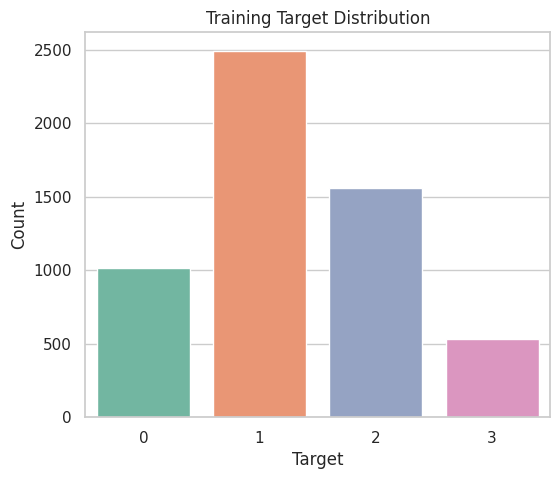


Missing Values:
sale_id                           0
gpu_model                         0
gpu_family                        0
launch_year                       0
region                            0
sales_channel                     0
customer_segment                  0
units_sold                        0
msrp_usd                          0
avg_street_price_usd              0
price_premium_pct                 0
stock_status                      0
customer_satisfaction_score       0
warranty_months                   0
bundle_addon                   3841
revenue_usd                       0
Year                              0
Month                             0
Quarter                           0
Day                               0
sale_year                         0
sale_month                        0
sale_day                          0
sale_weekday                      0
sale_quarter                      0
sale_week                         0
is_weekend                        0
dtype: int6

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================
# DATASET
# ============================================================

# If not already loaded:
# df = pd.read_csv("train.csv")

print("="*60)
print("Dataset Shape :", df.shape)
print("="*60)

display(df.head())

# ============================================================
# BASIC INFORMATION
# ============================================================

print(df.info())

print(df.describe(include="all"))

# ============================================================
# DUPLICATES
# ============================================================

print("Duplicate Rows :", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

# ============================================================
# DATE CONVERSION
# ============================================================

df["sale_date"] = pd.to_datetime(df["sale_date"])

# ============================================================
# FEATURE ENGINEERING
# ============================================================

df["sale_year"] = df["sale_date"].dt.year
df["sale_month"] = df["sale_date"].dt.month
df["sale_day"] = df["sale_date"].dt.day
df["sale_weekday"] = df["sale_date"].dt.dayofweek
df["sale_quarter"] = df["sale_date"].dt.quarter
df["sale_week"] = df["sale_date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = (df["sale_date"].dt.dayofweek >= 5).astype(int)

df.drop(columns=["sale_date"], inplace=True)

# ============================================================
# TARGET COLUMN
# ============================================================

TARGET = "stock_status"
ID = "sale_id"

# ============================================================
# LABEL ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

df[TARGET] = target_encoder.fit_transform(df[TARGET])

print("Target Classes:")
print(target_encoder.classes_)

# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Remove ID column
X = X.drop(columns=[ID])

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Validation Shape :", X_valid.shape)

# ============================================================
# NUMERICAL FEATURES
# ============================================================

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

# ============================================================
# CATEGORICAL FEATURES
# ============================================================

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nCategorical Features:")
print(categorical_features)

# ============================================================
# NUMERICAL PIPELINE
# ============================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ============================================================
# CATEGORICAL PIPELINE
# ============================================================

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ============================================================
# PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("\nPreprocessing Pipeline Created Successfully!")

# ============================================================
# TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x=y_train,
    palette="Set2"
)

plt.title("Training Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

# ============================================================
# MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# SUMMARY
# ============================================================

print("="*60)
print("Part 1 Completed Successfully")
print("="*60)

print("Training Samples :", len(X_train))
print("Validation Samples :", len(X_valid))
print("Number of Classes :", len(np.unique(y_train)))

Logistic Regression
Cross Validation Accuracy
[0.83392857 0.82767857 0.81607143 0.825      0.83839286]
Mean CV Accuracy : 0.8282142857142857

Accuracy : 0.8228571428571428
Precision : 0.8232192985672051
Recall : 0.8228571428571428
F1 Score : 0.8188828681384902

              precision    recall  f1-score   support

           0       0.65      0.73      0.69       254
           1       0.91      0.97      0.94       623
           2       0.81      0.75      0.77       389
           3       0.82      0.53      0.64       134

    accuracy                           0.82      1400
   macro avg       0.79      0.74      0.76      1400
weighted avg       0.82      0.82      0.82      1400



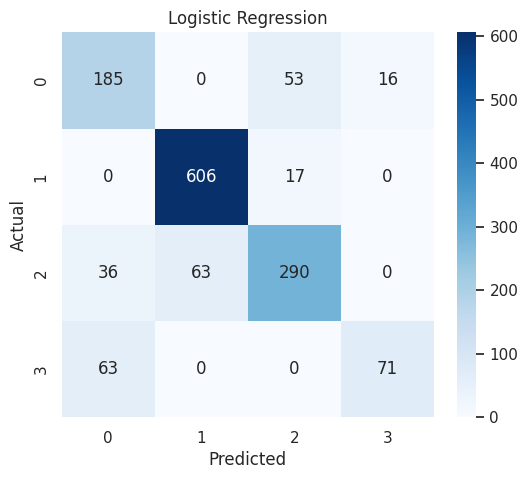


                 Model  CV Accuracy  Accuracy  Precision    Recall        F1  \
0  Logistic Regression     0.828214  0.822857   0.823219  0.822857  0.818883   

   ROC AUC  
0      NaN  



In [16]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# ============================================================
# CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ============================================================
# RESULT STORAGE
# ============================================================

results = []

trained_models = {}

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, pipeline):

    print("="*80)
    print(model_name)
    print("="*80)

    # -------------------------------------------------------
    # Cross Validation Accuracy
    # -------------------------------------------------------

    cv_scores = cross_val_score(

        pipeline,

        X_train,

        y_train,

        cv=cv,

        scoring="accuracy",

        n_jobs=-1

    )

    print("Cross Validation Accuracy")

    print(cv_scores)

    print("Mean CV Accuracy :", cv_scores.mean())

    print()

    # -------------------------------------------------------
    # Train Model
    # -------------------------------------------------------

    pipeline.fit(

        X_train,

        y_train

    )

    trained_models[model_name] = pipeline

    # -------------------------------------------------------
    # Prediction
    # -------------------------------------------------------

    y_pred = pipeline.predict(

        X_valid

    )

    # -------------------------------------------------------
    # Metrics
    # -------------------------------------------------------

    accuracy = accuracy_score(

        y_valid,

        y_pred

    )

    precision = precision_score(

        y_valid,

        y_pred,

        average="weighted"

    )

    recall = recall_score(

        y_valid,

        y_pred,

        average="weighted"

    )

    f1 = f1_score(

        y_valid,

        y_pred,

        average="weighted"

    )

    print("Accuracy :", accuracy)

    print("Precision :", precision)

    print("Recall :", recall)

    print("F1 Score :", f1)

    # -------------------------------------------------------
    # ROC AUC
    # -------------------------------------------------------

    roc = np.nan

    if len(np.unique(y_train)) == 2:

        probability = pipeline.predict_proba(

            X_valid

        )[:,1]

        roc = roc_auc_score(

            y_valid,

            probability

        )

        print("ROC AUC :", roc)

    # -------------------------------------------------------
    # Classification Report
    # -------------------------------------------------------

    print()

    print(classification_report(

        y_valid,

        y_pred

    ))

    # -------------------------------------------------------
    # Confusion Matrix
    # -------------------------------------------------------

    cm = confusion_matrix(

        y_valid,

        y_pred

    )

    plt.figure(figsize=(6,5))

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues"

    )

    plt.title(model_name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # -------------------------------------------------------
    # ROC Curve
    # -------------------------------------------------------

    if len(np.unique(y_train)) == 2:

        RocCurveDisplay.from_estimator(

            pipeline,

            X_valid,

            y_valid

        )

        plt.title(model_name)

        plt.show()

    # -------------------------------------------------------
    # Save Result
    # -------------------------------------------------------

    results.append({

        "Model":model_name,

        "CV Accuracy":cv_scores.mean(),

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1":f1,

        "ROC AUC":roc

    })

# ============================================================
# LOGISTIC REGRESSION PIPELINE
# ============================================================

logistic_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "classifier",

            LogisticRegression(

                max_iter=1000,

                random_state=RANDOM_STATE

            )

        )

    ]

)

# ============================================================
# TRAIN MODEL
# ============================================================

evaluate_model(

    "Logistic Regression",

    logistic_pipeline

)

# ============================================================
# RESULT TABLE
# ============================================================

result_df = pd.DataFrame(results)

print()

print(result_df)

print()



## Thank you...pls upvote!!!!!!!!!!!